In [2]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
DB_PATH = "ecommerce.db"
CLEANED_DIR = Path("cleaned_data")
CLEANED_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(DB_PATH)

## Phase 1 — SQL Analytics Queries

Load results from at least 4 queries (from `queries.sql`) into pandas DataFrames
and persist them to `cleaned_data/` for reuse in Phases 2–4.

Queries loaded:
1. **Category performance** — revenue, order count, AOV by category
2. **Top 20 customers** — lifetime spend, city, signup date
3. **Month-over-month revenue trend** — last 24 months with LAG window
4. **Category profitability** — margin after costs and discounts

In [4]:
SQL_QUERIES = {
    # Query 1: Category revenue + order count + AOV (net of discounts)
    "category_performance": """
        SELECT
            p.category,
            ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS total_revenue,
            COUNT(DISTINCT o.order_id) AS order_count,
            ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
        FROM products p
        JOIN order_items oi ON p.product_id = oi.product_id
        JOIN orders o ON oi.order_id = o.order_id
        GROUP BY p.category
    """,

    # Query 2: Top 20 customers by lifetime spend (net of discounts)
    "top_customers": """
        SELECT
            c.customer_id,
            c.name,
            c.city,
            c.signup_date,
            ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS lifetime_spend
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY c.customer_id, c.name, c.city, c.signup_date
        ORDER BY lifetime_spend DESC
        LIMIT 20
    """,

    # Query 3: MoM revenue trend — last 24 months with LAG window
    "monthly_revenue_trend": """
        WITH monthly_revenue AS (
            SELECT
                strftime('%Y-%m', o.order_date) AS month,
                ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS revenue
            FROM orders o
            JOIN order_items oi ON o.order_id = oi.order_id
            GROUP BY strftime('%Y-%m', o.order_date)
        )
        SELECT
            month,
            revenue,
            LAG(revenue) OVER (ORDER BY month) AS previous_month_revenue,
            ROUND(revenue - LAG(revenue) OVER (ORDER BY month), 2) AS mom_change
        FROM monthly_revenue
        ORDER BY month DESC
        LIMIT 24
    """,

    # Query 10: Profitability margin by category (net revenue - total cost)
    "category_profitability": """
        SELECT
            p.category,
            ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)), 2) AS net_revenue,
            ROUND(SUM(oi.quantity * p.cost), 2) AS total_cost,
            ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) - SUM(oi.quantity * p.cost), 2) AS net_profit,
            ROUND(
                (SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) - SUM(oi.quantity * p.cost))
                / SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) * 100, 2
            ) AS profit_margin_pct
        FROM products p
        JOIN order_items oi ON p.product_id = oi.product_id
        GROUP BY p.category
        ORDER BY profit_margin_pct ASC
    """,
}

# Load all queries into a dictionary of DataFrames
dataframes = {}
for name, query in SQL_QUERIES.items():
    dataframes[name] = pd.read_sql_query(query, conn)

conn.close()
print(f"Loaded {len(dataframes)} query results into pandas DataFrames")

Loaded 4 query results into pandas DataFrames


In [5]:
# Extract individual DataFrames with descriptive names
df_categories = dataframes["category_performance"]
df_top_customers = dataframes["top_customers"]
df_monthly_trend = dataframes["monthly_revenue_trend"]
df_profitability = dataframes["category_profitability"]

print("=== Category Performance ===")
display(df_categories)

print("\n=== Top 20 Customers (LTV) ===")
display(df_top_customers.head())

print("\n=== Monthly Revenue Trend (last 5 months) ===")
display(df_monthly_trend.head())

print("\n=== Category Profitability ===")
display(df_profitability)

=== Category Performance ===


,category,total_revenue,order_count,avg_order_value
0,Apparel,1714435.76,2854,600.71
1,Beauty & Health,2957229.75,2821,1048.29
2,Books & Media,3675270.95,2927,1255.64
3,Electronics,1653446.70,2891,571.93
4,Home & Kitchen,1414051.56,2927,483.11
5,Sports & Outdoors,1664660.63,2820,590.31



=== Top 20 Customers (LTV) ===


,customer_id,name,city,signup_date,lifetime_spend
0,611,Tara Holmes,Sydney,2021-10-15,146989.77
1,689,Misty Mcguire,Toronto,2020-08-25,108053.55
2,2181,Jason Ramirez,Melbourne,2019-11-08,106449.54
3,1259,Matthew Perez,Los Angeles,2023-02-25,95535.58
4,1773,Connie Hamilton,Los Angeles,2022-02-13,80201.62



=== Monthly Revenue Trend (last 5 months) ===


,month,revenue,previous_month_revenue,mom_change
0,2024-12,487110.89,613266.89,-126156.00
1,2024-11,613266.89,451798.01,161468.88
2,2024-10,451798.01,485928.43,-34130.42
3,2024-09,485928.43,598514.65,-112586.22
4,2024-08,598514.65,523334.67,75179.98



=== Category Profitability ===


,category,net_revenue,total_cost,net_profit,profit_margin_pct
0,Home & Kitchen,1414051.56,743020.13,671031.43,47.45
1,Apparel,1714435.76,875450.54,838985.22,48.94
2,Sports & Outdoors,1664660.63,824854.34,839806.29,50.45
3,Electronics,1653446.70,783224.60,870222.10,52.63
4,Beauty & Health,2957229.75,858556.67,2098673.08,70.97
5,Books & Media,3675270.95,815642.08,2859628.87,77.81


## Phase 2 — Data Cleaning & Integration

Reconcile the three data sources (DB tables, `legacy_customers_export.csv`,
`product_catalog_2024.csv`) into clean, analysis-ready DataFrames.

1. Standardize legacy CSV date formats
2. Detect & resolve duplicate customer records
3. Missing-value policy (age, city, gender, review_text)
4. Price outliers (z-score)
5. Merge product catalog with products table
6. Deduplicate order_items & handle returns
7. Reshape (`pivot_table`)
8. Time-series (`resample`)

In [6]:
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Reconnect to DB for Phase 2
conn2 = sqlite3.connect(DB_PATH)

# Load all DB tables into pandas
db_customers   = pd.read_sql_query("SELECT * FROM customers", conn2)
db_products    = pd.read_sql_query("SELECT * FROM products", conn2)
db_orders      = pd.read_sql_query("SELECT * FROM orders", conn2)
db_order_items = pd.read_sql_query("SELECT * FROM order_items", conn2)
db_reviews     = pd.read_sql_query("SELECT * FROM reviews", conn2)
db_web_sessions = pd.read_sql_query("SELECT * FROM web_sessions", conn2)

# Load CSVs
legacy_raw = pd.read_csv("legacy_customers_export.csv")
catalog_raw = pd.read_csv("product_catalog_2024.csv")

# Record row counts before cleaning
before_counts = {
    "db_customers": len(db_customers),
    "db_products": len(db_products),
    "db_orders": len(db_orders),
    "db_order_items": len(db_order_items),
    "db_reviews": len(db_reviews),
    "db_web_sessions": len(db_web_sessions),
    "legacy_export": len(legacy_raw),
    "product_catalog": len(catalog_raw),
}
print("Raw row counts:")
for k, v in before_counts.items():
    print(f"  {k}: {v}")

Raw row counts:
  db_customers: 2500
  db_products: 300
  db_orders: 9000
  db_order_items: 20362
  db_reviews: 4000
  db_web_sessions: 12000
  legacy_export: 1427
  product_catalog: 267


### 2.1 Standardize Legacy Customer Dates

The legacy CSV has trailing whitespace in column names and four different date formats:

| Format | Example |
|---|---|
| `%d-%b-%Y` | `30-Nov-2023` |
| `%B %d, %Y` | `August 19, 2020` |
| `%m/%d/%Y` | `07/05/2023` |
| `%Y-%m-%d` | `2019-09-25` |

Strategy: strip column names, try `pd.to_datetime` with `dayfirst=True` first,
then use `pd.to_datetime(errors='coerce')` and parse failures with each specific format.

In [7]:
# Strip trailing whitespace from column names
legacy_raw.columns = legacy_raw.columns.str.strip()
print("Cleaned column names:", legacy_raw.columns.tolist())

# Try parsing with dayfirst first
dates = pd.to_datetime(legacy_raw["Signup_Dt"], dayfirst=True, errors="coerce")
na_mask = dates.isna()
print(f"Failed to parse with dayfirst=True: {na_mask.sum()} rows")

# Parse failures with specific format attempts
failed_values = legacy_raw.loc[na_mask, "Signup_Dt"]

def parse_date_fallback(series):
    formats = ["%B %d, %Y", "%m/%d/%Y", "%Y-%m-%d"]
    for fmt in formats:
        parsed = pd.to_datetime(series, format=fmt, errors="coerce")
        return parsed

# Try each format on the remaining NAs
for fmt in ["%B %d, %Y", "%m/%d/%Y", "%Y-%m-%d"]:
    still_na = dates.isna()
    if still_na.sum() == 0:
        break
    parsed = pd.to_datetime(legacy_raw.loc[still_na, "Signup_Dt"], format=fmt, errors="coerce")
    dates.loc[still_na] = parsed.loc[still_na]

legacy_raw["signup_date_clean"] = dates
still_missing = dates.isna().sum()
print(f"Dates still unparseable: {still_missing}")
print("Sample of parsed dates:")
print(legacy_raw[["Signup_Dt", "signup_date_clean"]].head(10))

Cleaned column names: ['Customer Name', 'EMAIL_ADDR', 'Signup_Dt', 'Home City', 'Marketing Segment']
Failed to parse with dayfirst=True: 1055 rows
Dates still unparseable: 1
Sample of parsed dates:
         Signup_Dt signup_date_clean
0      30-Nov-2023        2023-11-30
1      01-Aug-2021        2021-08-01
2      27-May-2021        2021-05-27
3  August 19, 2020        2020-08-19
4       07/05/2023        2023-07-05
5       01/25/2021        2021-01-25
6  August 23, 2023        2023-08-23
7     May 05, 2022        2022-05-05
8       04/01/2024        2024-04-01
9      23-Jan-2023        2023-01-23


### 2.2 Detect & Resolve Duplicate Customer Records

- **Exact duplicates**: drop outright
- **Blank rows**: drop rows where all values are NaN or empty
- **Near-duplicates** (same email, different name casing): group by `EMAIL_ADDR` (lowercased),
  keep the record with the latest signup date, normalize name to title case
- **Test accounts**: flag and drop rows with "test" in name or email

In [8]:
legacy = legacy_raw.copy()

# Drop blank rows (all NaN)
blank_before = len(legacy)
legacy = legacy.dropna(how="all")
print(f"Dropped {blank_before - len(legacy)} blank rows")

# Drop rows with missing email (can't match without it)
before_email = len(legacy)
legacy = legacy[legacy["EMAIL_ADDR"].notna() & (legacy["EMAIL_ADDR"].str.strip() != "")]
print(f"Dropped {before_email - len(legacy)} rows with missing email")

# Flag and drop test accounts
test_mask = (
    legacy["EMAIL_ADDR"].str.lower().str.contains("test", na=False) |
    legacy["Customer Name"].str.lower().str.contains("test", na=False)
)
print(f"Dropped {test_mask.sum()} test accounts")
legacy = legacy[~test_mask]

# Exact duplicates
exact_dupes = legacy.duplicated().sum()
legacy = legacy.drop_duplicates()
print(f"Dropped {exact_dupes} exact duplicates")

# Near-duplicates: same email, different name casing
legacy["email_lower"] = legacy["EMAIL_ADDR"].str.lower()
dup_emails = legacy[legacy["email_lower"].duplicated(keep=False)]

# For same-email groups: keep latest signup, normalize name
legacy = legacy.sort_values("signup_date_clean", ascending=False)
legacy = legacy.drop_duplicates(subset="email_lower", keep="first")
legacy["Customer Name"] = legacy["Customer Name"].str.strip().str.title()
legacy = legacy.drop(columns=["email_lower"])

fuzzy_dupes_removed = len(dup_emails) - dup_emails["email_lower"].nunique()
print(f"Resolved {fuzzy_dupes_removed} near-duplicate records (same email, different name)")
print(f"Legacy customers after cleaning: {len(legacy)}")

Dropped 1 blank rows
Dropped 56 rows with missing email
Dropped 1 test accounts
Dropped 0 exact duplicates
Resolved 48 near-duplicate records (same email, different name)
Legacy customers after cleaning: 1321


### 2.3 Missing Value Policy

**Before/after summary for DB customers**:

| Column | Missing Before | % | Strategy |
|---|---|---|---|
| `city` | 63 | 2.5% | Fill `"Unknown"` — cannot safely impute geography |
| `age` | 139 | 5.6% | Impute with **median** by gender (avoids mean skew from outliers) |
| `gender` | 115 | 4.6% | Fill `"Unknown"` — categorical, no safe guess |
| `review_text` | 838 | 20.9% | Keep NaN, add `has_review_text` flag column — free text is un-imputable |

Justification: median is chosen over mean for `age` because age distributions can be skewed.
Median is robust to outliers. For categorical columns, `"Unknown"` preserves the fact of missingness
rather than silently fabricating data. For free text, the absence itself is a signal (verified
purchaser vs not).

In [9]:
# DB customers
print(f"\n=== customers: before ===")
print(f"  city missing:   {db_customers['city'].isna().sum()}")
print(f"  age missing:    {db_customers['age'].isna().sum()}")
print(f"  gender missing: {db_customers['gender'].isna().sum()}")

db_customers_clean = db_customers.copy()
db_customers_clean["city"] = db_customers_clean["city"].fillna("Unknown")
db_customers_clean["gender"] = db_customers_clean["gender"].fillna("Unknown")

# Impute age with median by gender group
db_customers_clean["age"] = db_customers_clean.groupby("gender")["age"].transform(
    lambda x: x.fillna(x.median())
)
# If any still NaN (e.g. all-missing group), fill with overall median
db_customers_clean["age"] = db_customers_clean["age"].fillna(db_customers_clean["age"].median())

print(f"\n=== customers: after ===")
print(f"  city missing:   {db_customers_clean['city'].isna().sum()}")
print(f"  age missing:    {db_customers_clean['age'].isna().sum()}")
print(f"  gender missing: {db_customers_clean['gender'].isna().sum()}")

# Reviews: flag missing text
db_reviews_clean = db_reviews.copy()
db_reviews_clean["has_review_text"] = db_reviews_clean["review_text"].notna().astype(int)
print(f"\nReviews with missing text: {db_reviews_clean['review_text'].isna().sum()} "
      f"({db_reviews_clean['review_text'].isna().mean()*100:.1f}%)")
print(f"Reviews with text flag set: {db_reviews_clean['has_review_text'].sum()}")


=== customers: before ===
  city missing:   63
  age missing:    139
  gender missing: 115

=== customers: after ===
  city missing:   0
  age missing:    0
  gender missing: 0

Reviews with missing text: 838 (20.9%)
Reviews with text flag set: 3162


### 2.4 Price Outliers — z-score Method

Formula: $z = \frac{x - \mu}{\sigma}$

Threshold: $|z| > 3$ (3 standard deviations). In a normal distribution ~99.7% of values
fall within 3-sigma, so points beyond this are strong outliers.

Apply to both `products.unit_price` (DB) and `product_catalog_2024.list_price_usd` (CSV).
Outliers are **capped** at the 3-sigma boundary rather than removed, to preserve row counts
for downstream analysis.

In [10]:
def flag_outliers_zscore(series, threshold=3):
    """Return (outlier_mask, lower_bound, upper_bound) for z-score method."""
    z = stats.zscore(series.dropna())
    mean, std = series.mean(), series.std()
    lower = mean - threshold * std
    upper = mean + threshold * std
    return (abs(z) > threshold), lower, upper

# DB products
db_products_clean = db_products.copy()
mask, lo, hi = flag_outliers_zscore(db_products_clean["unit_price"])

db_products_clean["price_outlier"] = False
db_products_clean.loc[db_products_clean["unit_price"].dropna().index[mask], "price_outlier"] = True

print(f"=== DB products ===")
print(f"  unit_price mean: {db_products_clean['unit_price'].mean():.2f}, std: {db_products_clean['unit_price'].std():.2f}")
print(f"  z-score bounds:  [{lo:.2f}, {hi:.2f}]")
print(f"  Outliers flagged (|z|>3): {db_products_clean['price_outlier'].sum()}")
outlier_products = db_products_clean[db_products_clean["price_outlier"]]
if len(outlier_products) > 0:
    print(outlier_products[["product_id", "name", "category", "unit_price"]].to_string())

# Cap outliers at the boundary
db_products_clean["unit_price"] = db_products_clean["unit_price"].clip(lower=lo, upper=hi)

# Product catalog CSV
catalog_clean = catalog_raw.copy()
cat_mask, cat_lo, cat_hi = flag_outliers_zscore(catalog_clean["list_price_usd"])
catalog_clean["price_outlier"] = False
catalog_clean.loc[catalog_clean["list_price_usd"].dropna().index[cat_mask], "price_outlier"] = True

print(f"\n=== Product catalog ===")
print(f"  list_price_usd mean: {catalog_clean['list_price_usd'].mean():.2f}, std: {catalog_clean['list_price_usd'].std():.2f}")
print(f"  z-score bounds:  [{cat_lo:.2f}, {cat_hi:.2f}]")
print(f"  Outliers flagged (|z|>3): {catalog_clean['price_outlier'].sum()}")
outlier_cat = catalog_clean[catalog_clean["price_outlier"]]
if len(outlier_cat) > 0:
    print(outlier_cat[["SKU", "item_name", "dept", "list_price_usd"]].to_string())

catalog_clean["list_price_usd"] = catalog_clean["list_price_usd"].clip(lower=cat_lo, upper=cat_hi)
catalog_clean["supplier_cost"] = catalog_clean["supplier_cost"].clip(lower=0)

=== DB products ===
  unit_price mean: 576.95, std: 2150.90
  z-score bounds:  [-5875.76, 7029.66]
  Outliers flagged (|z|>3): 3
     product_id                       name         category  unit_price
244         245   Throughout Personal Care  Beauty & Health     11506.5
249         250          Discover Haircare  Beauty & Health      8284.0
269         270  Environmental Non-Fiction    Books & Media     34872.0

=== Product catalog ===
  list_price_usd mean: 593.00, std: 2274.89
  z-score bounds:  [-6231.67, 7417.68]
  Outliers flagged (|z|>3): 3
     SKU                  item_name             dept  list_price_usd
4    245   Throughout Personal Care  Beauty & Health    11782.864608
45   270  Environmental Non-Fiction    Books & Media    34712.370303
245  250          Discover Haircare  Beauty & Health     8289.762318


### 2.5 Merge Product Catalog with Products Table

- `catalog.SKU` maps to `products.product_id`
- `catalog.dept` maps to `products.category`
- Standardize column names to lowercase
- Report: SKUs in both / catalog-only / DB-only

In [11]:
# Standardize catalog column names
catalog_clean.columns = [c.lower().replace(" ", "_") for c in catalog_clean.columns]

# Keys for merge
catalog_sku_set = set(catalog_clean["sku"])
db_product_set  = set(db_products_clean["product_id"])

both       = catalog_sku_set & db_product_set
cat_only   = catalog_sku_set - db_product_set
db_only    = db_product_set - catalog_sku_set

print(f"SKUs in both sources:          {len(both)}")
print(f"SKUs only in catalog CSV:       {len(cat_only)}")
print(f"SKUs only in DB products table: {len(db_only)}")

if len(cat_only) > 0:
    print(f"\nCatalog-only SKUs (first 10): {sorted(list(cat_only))[:10]}")

# Merge on SKU = product_id
merged_catalog = db_products_clean.merge(
    catalog_clean,
    left_on="product_id",
    right_on="sku",
    how="outer",
    indicator=True,
    suffixes=("_db", "_cat")
)
print(f"\nMerge result: {len(merged_catalog)} rows")
print(merged_catalog["_merge"].value_counts().to_string())

SKUs in both sources:          255
SKUs only in catalog CSV:       12
SKUs only in DB products table: 45

Catalog-only SKUs (first 10): [9000, 9001, 9002, 9003, 9004, 9005, 9006, 9007, 9008, 9009]

Merge result: 312 rows
_merge
both          255
left_only      45
right_only     12


### 2.6 Deduplicate order_items & Handle Returns

- ~0.91% exact duplicate rows (excluding PK) — drop them
- Negative `quantity` = return — split into `order_items_sales` (qty > 0) and
  `order_items_returns` (qty < 0) for separate handling
- Revenue calculations should use only positive quantities

In [12]:
oi = db_order_items.copy()

# Deduplicate (exclude PK order_item_id)
cols_excl_pk = [c for c in oi.columns if c != "order_item_id"]
dup_count = oi.duplicated(subset=cols_excl_pk).sum()
print(f"Exact duplicates (excl PK): {dup_count} ({dup_count/len(oi)*100:.2f}%)")
oi = oi.drop_duplicates(subset=cols_excl_pk)
print(f"After dedup: {len(oi)} rows")

# Split into sales (positive qty) and returns (negative qty)
oi_sales = oi[oi["quantity"] > 0].copy()
oi_returns = oi[oi["quantity"] < 0].copy()

print(f"Sales items:     {len(oi_sales)} rows")
print(f"Return items:    {len(oi_returns)} rows")

# Add revenue column (sales only) — net of discount
oi_sales["revenue"] = (
    oi_sales["quantity"] * oi_sales["unit_price"] * (1 - oi_sales["discount"])
)

Exact duplicates (excl PK): 186 (0.91%)
After dedup: 20176 rows
Sales items:     19599 rows
Return items:    577 rows


### 2.7 Reshape — Category x Month Revenue Matrix

Using `pivot_table` to create a wide-format matrix: rows = category, columns = month,
values = total revenue (net of discounts, sales only).

In [13]:
# Build a denormalized sales view
sales_denorm = oi_sales.merge(db_orders[["order_id", "order_date"]], on="order_id")
sales_denorm = sales_denorm.merge(
    db_products_clean[["product_id", "category"]], on="product_id"
)

# Extract year-month
sales_denorm["year_month"] = pd.to_datetime(sales_denorm["order_date"]).dt.strftime("%Y-%m")

# Pivot: category x month revenue
pivot_cat_month = sales_denorm.pivot_table(
    values="revenue",
    index="category",
    columns="year_month",
    aggfunc="sum",
    fill_value=0
)

print(f"Pivot shape: {pivot_cat_month.shape}  (categories x months)")
display(pivot_cat_month)

Pivot shape: (6, 36)  (categories x months)


year_month,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,...,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
category,,,,,,,,,,,,,,,,,,,,,
Apparel,22903.5170,26033.7170,28607.8235,33917.4625,31137.7205,33641.8345,33026.3210,25550.9315,30647.7665,37575.0850,...,69263.2965,54113.8780,68278.7070,67170.4725,73898.9740,78103.4480,69425.6080,64879.9245,61876.0335,70235.4080
Beauty & Health,60052.7415,42804.2750,19089.8630,53362.5600,69123.9540,59250.3150,104647.7690,97886.3915,65168.2760,80509.9590,...,73689.7980,66220.9215,138766.9335,76727.5565,115880.5050,99097.9890,100528.6995,106609.1770,189649.2365,134670.8025
Books & Media,128047.8250,27176.9025,92247.1705,20361.3905,96241.5155,27125.7965,125992.5385,24536.7105,59267.8130,90188.8025,...,188906.7965,159952.9950,130046.0305,194808.5390,138087.8080,240783.6905,150734.2825,98254.7505,161558.8635,98283.6040
Electronics,25886.2910,18994.0535,29287.7120,32302.2195,37951.2845,24574.6465,29341.7780,35440.2185,39330.9575,31964.5145,...,49762.0850,55905.6455,59109.6685,56464.5955,67215.6125,68103.8900,68679.1630,67651.6150,79024.5085,78951.1095
Home & Kitchen,26523.4810,20884.8125,25163.3990,15874.4865,16810.6400,27154.8630,28391.9485,29298.3695,29119.3050,32714.9170,...,42845.8525,42034.8595,65573.4105,49400.0345,66349.5800,69837.3040,44930.3195,63555.1675,55074.0730,54924.5610
Sports & Outdoors,30416.6585,29054.9625,32188.0255,20758.4390,35328.9315,35887.6300,29409.6630,38390.0890,26833.0770,32098.7750,...,56146.7090,63350.9220,62698.9055,61228.2555,79537.6750,78953.8820,54021.2520,68084.2935,70572.0795,61859.8990


### 2.8 Time-Series — Weekly Active Customers

Number of distinct customers who placed at least one order in each calendar week,
using `resample('W')` on a datetime index.

Weeks of data: 158
Mean weekly active: 56


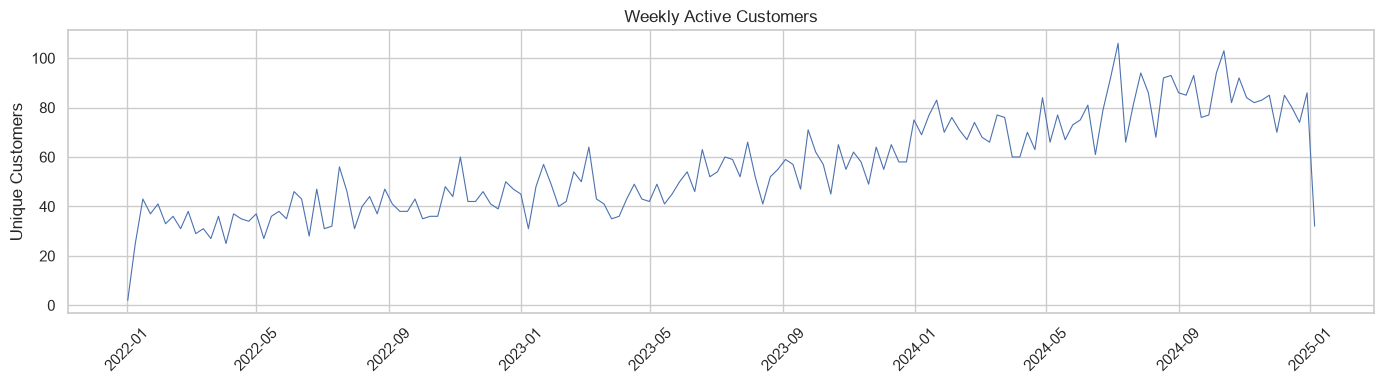

In [14]:
# Prepare orders with datetime index
orders_ts = db_orders.copy()
orders_ts["order_date"] = pd.to_datetime(orders_ts["order_date"])
orders_ts = orders_ts.set_index("order_date").sort_index()

# Weekly active customers
weekly_active = orders_ts.resample("W")["customer_id"].nunique()
weekly_active = weekly_active.reset_index()
weekly_active.columns = ["week_start", "active_customers"]

print(f"Weeks of data: {len(weekly_active)}")
print(f"Mean weekly active: {weekly_active['active_customers'].mean():.0f}")

# Quick plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_active["week_start"], weekly_active["active_customers"], linewidth=0.8)
ax.set_title("Weekly Active Customers")
ax.set_ylabel("Unique Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.9 Save Clean Data to `data/processed/`

In [15]:
# Clean out-of-range reviews ratings (valid: 1-5)
db_reviews_clean.loc[
    (db_reviews_clean["rating"] < 1) | (db_reviews_clean["rating"] > 5), "rating"
] = np.nan
oob = db_reviews_clean["rating"].isna().sum() - db_reviews["rating"].isna().sum()
print(f"Set {oob} out-of-range ratings to NaN (were outside 1-5)")

# Convert date columns in DB tables to datetime strings for consistent CSV output
db_orders_clean = db_orders.copy()
db_orders_clean["order_date"] = pd.to_datetime(db_orders_clean["order_date"])

db_customers_clean["signup_date"] = pd.to_datetime(db_customers_clean["signup_date"])
db_reviews_clean["review_date"] = pd.to_datetime(db_reviews_clean["review_date"])
db_web_sessions_clean = db_web_sessions.copy()
db_web_sessions_clean["session_date"] = pd.to_datetime(db_web_sessions_clean["session_date"])

# Save all clean CSVs
EXPORTS_P2 = {
    "clean_customers.csv":      db_customers_clean,
    "clean_products.csv":        db_products_clean,
    "clean_orders.csv":          db_orders_clean,
    "clean_order_items_sales.csv": oi_sales,
    "clean_order_items_returns.csv": oi_returns,
    "clean_reviews.csv":         db_reviews_clean,
    "clean_web_sessions.csv":    db_web_sessions_clean,
    "clean_legacy_customers.csv": legacy,
    "merged_product_catalog.csv": merged_catalog,
    "pivot_category_monthly_revenue.csv": pivot_cat_month,
    "weekly_active_customers.csv": weekly_active,
}

for filename, df in EXPORTS_P2.items():
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {path}  ({len(df)} rows)")

conn2.close()
print("\nPhase 2 complete. Clean data saved to data/processed/")

Set 41 out-of-range ratings to NaN (were outside 1-5)
Saved data\processed\clean_customers.csv  (2500 rows)
Saved data\processed\clean_products.csv  (300 rows)
Saved data\processed\clean_orders.csv  (9000 rows)
Saved data\processed\clean_order_items_sales.csv  (19599 rows)
Saved data\processed\clean_order_items_returns.csv  (577 rows)
Saved data\processed\clean_reviews.csv  (4000 rows)
Saved data\processed\clean_web_sessions.csv  (12000 rows)
Saved data\processed\clean_legacy_customers.csv  (1321 rows)
Saved data\processed\merged_product_catalog.csv  (312 rows)
Saved data\processed\pivot_category_monthly_revenue.csv  (6 rows)
Saved data\processed\weekly_active_customers.csv  (158 rows)

Phase 2 complete. Clean data saved to data/processed/


## Phase 3 — Numerical Analysis with NumPy

**Constraint**: Pandas convenience methods are **not allowed** for core computation.
All math must be implemented on raw NumPy arrays using `np.dot`, `np.linalg`, `np.random`, etc.
Each routine includes the mathematical formula, explanation, and a sanity-check validation.

1. **RFM Segmentation** — manual quintile bucketing (no `pd.qcut`)
2. **Cosine Similarity** — product recommendations via `np.dot` / `np.linalg.norm` (no sklearn/scipy shortcuts)
3. **Linear Regression** — normal equation β = (XᵀX)⁻¹Xᵀy via `np.linalg.inv`
4. **Monte Carlo Simulation** — stockout probability with ≥5,000 trials via `np.random`

### 3.1 RFM Segmentation

**Formula**:

- $R$ = days since last purchase (reference date = max order date)
- $F$ = distinct order count per customer
- $M$ = total revenue (net of discounts, sales only)
- $\text{RFM\_score} = Q(R) + Q(F) + Q(M)$ where $Q$ maps to quintile $\{1,2,3,4,5\}$

For Recency, **lower is better** (more recent = higher score), so quintile order is reversed.
For Frequency and Monetary, higher is better.

Bucketing uses `np.percentile` + `np.digitize` — no `pd.qcut`.

In [16]:
# Load clean data
orders_clean = pd.read_csv("data/processed/clean_orders.csv")
sales_clean  = pd.read_csv("data/processed/clean_order_items_sales.csv")
customers_clean = pd.read_csv("data/processed/clean_customers.csv")

# Merge sales with orders to get customer_id
rfm_data = sales_clean.merge(orders_clean[["order_id", "customer_id", "order_date"]], on="order_id")
rfm_data["order_date"] = pd.to_datetime(rfm_data["order_date"])

# Reference date = max order date
ref_date = rfm_data["order_date"].max()
print(f"Reference date: {ref_date}")

# Compute R, F, M per customer as NumPy arrays
customer_ids = np.sort(rfm_data["customer_id"].unique())
n_customers = len(customer_ids)

R = np.zeros(n_customers)
F = np.zeros(n_customers)
M = np.zeros(n_customers)

for i, cid in enumerate(customer_ids):
    cust = rfm_data[rfm_data["customer_id"] == cid]
    R[i] = (ref_date - cust["order_date"].max()).days
    F[i] = cust["order_id"].nunique()
    M[i] = cust["revenue"].sum()

print(f"Customers: {n_customers}")
print(f"Recency range:    {R.min():.0f} - {R.max():.0f} days")
print(f"Frequency range:  {F.min():.0f} - {F.max():.0f} orders")
print(f"Monetary range:   {M.min():.2f} - {M.max():.2f}")

Reference date: 2024-12-31 23:58:14
Customers: 2435
Recency range:    0 - 1094 days
Frequency range:  1 - 11 orders
Monetary range:   14.73 - 146989.77


In [17]:
# Manual quintile scoring (1-5) using np.percentile + np.digitize
def quintile_score(values, reverse=False):
    """Assign 1-5 score based on percentile buckets. If reverse=True, lower values get higher scores."""
    boundaries = np.percentile(values, [20, 40, 60, 80])
    bins = np.concatenate([[-np.inf], boundaries, [np.inf]])
    scores = np.digitize(values, bins[1:-1], right=True) + 1
    if reverse:
        scores = 6 - scores
    return scores.astype(int)

R_score = quintile_score(R, reverse=True)   # lower recency = better
F_score = quintile_score(F, reverse=False)   # higher frequency = better
M_score = quintile_score(M, reverse=False)   # higher monetary = better

rfm_total = R_score + F_score + M_score

# Segment labels
def segment_label(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal"
    elif score >= 7:
        return "Potential"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost"

segments = np.array([segment_label(s) for s in rfm_total])

print("=== RFM Score Distribution ===")
for seg in ["Champions", "Loyal", "Potential", "At Risk", "Lost"]:
    count = np.sum(segments == seg)
    avg_rev = np.mean(M[segments == seg]) if count > 0 else 0
    print(f"  {seg:12s}: {count:4d} customers,  avg revenue = ${avg_rev:,.2f}")

print(f"\nRFM score range: {rfm_total.min()}-{rfm_total.max()}")

=== RFM Score Distribution ===
  Champions   :  368 customers,  avg revenue = $11,768.56
  Loyal       :  646 customers,  avg revenue = $7,106.22
  Potential   :  717 customers,  avg revenue = $4,529.29
  At Risk     :  378 customers,  avg revenue = $2,121.37
  Lost        :  326 customers,  avg revenue = $1,209.69

RFM score range: 3-15


In [18]:
# Sanity check: verify 2 customers manually
print("=== Sanity Check ===")
sample_cid = customer_ids[0]
idx = np.where(customer_ids == sample_cid)[0][0]
print(f"Customer {sample_cid}: R={R[idx]:.0f}d, F={F[idx]:.0f}, M={M[idx]:.2f}")
print(f"  Scores: R={R_score[idx]}, F={F_score[idx]}, M={M_score[idx]} => RFM={rfm_total[idx]} => {segments[idx]}")

# Verify quintile boundaries make sense
print(f"\nR quintile boundaries (20/40/60/80): {np.percentile(R, [20,40,60,80])}")
print(f"F quintile boundaries (20/40/60/80): {np.percentile(F, [20,40,60,80])}")
print(f"M quintile boundaries (20/40/60/80): {np.percentile(M, [20,40,60,80])}")

# Save for Phase 4
df_rfm = pd.DataFrame({
    "customer_id": customer_ids,
    "recency_days": R,
    "frequency": F,
    "monetary": M,
    "r_score": R_score,
    "f_score": F_score,
    "m_score": M_score,
    "rfm_score": rfm_total,
    "segment": segments,
})
df_rfm.to_csv("data/result_for_phase3/rfm_segments.csv", index=False)
print(f"\nSaved rfm_segments.csv ({len(df_rfm)} customers)")

=== Sanity Check ===
Customer 1: R=372d, F=3, M=2286.37
  Scores: R=1, F=2, M=2 => RFM=5 => At Risk

R quintile boundaries (20/40/60/80): [ 45. 106. 201. 370.]
F quintile boundaries (20/40/60/80): [2. 3. 4. 5.]
M quintile boundaries (20/40/60/80): [1783.3434 3069.2403 4399.2011 6671.0706]

Saved rfm_segments.csv (2435 customers)


### 3.2 Cosine Similarity — Product Recommendations

**Formula**:

$$\text{cos\_sim}(A,B) = \frac{A \cdot B}{\|A\| \cdot \|B\|} = \frac{\sum a_i b_i}{\sqrt{\sum a_i^2} \cdot \sqrt{\sum b_i^2}}$$

- Build customer-product matrix $M$ where $M_{i,j}$ = total quantity of product $j$ purchased by customer $i$
- Compute pairwise similarity: $S = M M^\top \oslash (\|M\| \otimes \|M\|)$
- For 5 sample customers: find top-3 most similar, recommend 3 products they haven't bought
- No `sklearn.metrics.pairwise.cosine_similarity` — use `np.dot` and `np.linalg.norm`

In [19]:
# Build customer-product matrix
pivot = rfm_data.pivot_table(
    index="customer_id", columns="product_id", values="quantity", aggfunc="sum", fill_value=0
)
cp_matrix = pivot.values.astype(np.float64)  # numpy array (customers x products)
cp_cust_ids = pivot.index.values

print(f"Customer-product matrix shape: {cp_matrix.shape}")
print(f"Sparsity: {np.mean(cp_matrix == 0)*100:.1f}% zeros")

# Compute cosine similarity using np.dot and np.linalg.norm
norms = np.linalg.norm(cp_matrix, axis=1)  # L2 norm per row
norms[norms == 0] = 1e-10                  # avoid division by zero

dot_products = np.dot(cp_matrix, cp_matrix.T)
outer_norms  = np.outer(norms, norms)
sim_matrix   = dot_products / outer_norms

# Zero out self-similarity for recommendations
np.fill_diagonal(sim_matrix, 0)
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Sim range: [{sim_matrix.min():.6f}, {sim_matrix.max():.6f}]")

Customer-product matrix shape: (2435, 300)
Sparsity: 97.4% zeros
Similarity matrix shape: (2435, 2435)
Sim range: [0.000000, 1.000000]


In [20]:
# Recommend 3 products for 5 sample customers
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(cp_cust_ids), size=5, replace=False)

product_ids = pivot.columns.values
print("=== Product Recommendations for 5 Sample Customers ===\n")

for idx in sample_indices:
    cid = cp_cust_ids[idx]
    # Find top-3 most similar customers (excluding self)
    sims = sim_matrix[idx]
    top3_idx = np.argsort(sims)[-3:][::-1]

    # Products bought by similar customers but NOT by this customer
    bought_by_sample = set(np.where(cp_matrix[idx] > 0)[0])
    rec_counts = np.zeros(len(product_ids))
    for ni in top3_idx:
        rec_counts += cp_matrix[ni]
    # Exclude already-bought products
    for p in bought_by_sample:
        rec_counts[p] = 0

    top3_rec = np.argsort(rec_counts)[-3:][::-1]

    cust_name = customers_clean.loc[customers_clean["customer_id"] == cid, "name"].values[0]
    print(f"Customer {cid} ({cust_name}):")
    for ri in top3_rec:
        prod_name = rfm_data.loc[rfm_data["product_id"] == product_ids[ri], "product_id"].values
        print(f"  Recommend product {product_ids[ri]} (score: {rec_counts[ri]:.1f})")
    print()

=== Product Recommendations for 5 Sample Customers ===

Customer 1932 (Sarah Robinson):
  Recommend product 71 (score: 2.0)
  Recommend product 22 (score: 1.0)
  Recommend product 141 (score: 1.0)

Customer 1098 (Shawn Lozano):
  Recommend product 2 (score: 2.0)
  Recommend product 163 (score: 1.0)
  Recommend product 32 (score: 1.0)

Customer 1633 (Carl Hunter):
  Recommend product 228 (score: 1.0)
  Recommend product 178 (score: 1.0)
  Recommend product 262 (score: 1.0)

Customer 219 (Chad Baldwin):
  Recommend product 61 (score: 2.0)
  Recommend product 24 (score: 1.0)
  Recommend product 235 (score: 1.0)

Customer 1083 (Anne Castillo):
  Recommend product 227 (score: 1.0)
  Recommend product 205 (score: 1.0)
  Recommend product 262 (score: 1.0)



In [21]:
# Sanity check: identical vector should have similarity = 1.0
print("=== Sanity Check ===")
v1 = cp_matrix[0].copy()
v2 = cp_matrix[0].copy()
cos_sim_self = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
print(f"Self-similarity: {cos_sim_self:.6f} (expected: 1.0)")

# Orthogonal vectors should have similarity = 0
v3 = np.array([1, 0, 0, 0, 0])
v4 = np.array([0, 1, 0, 0, 0])
cos_sim_orth = np.dot(v3, v4) / (np.linalg.norm(v3) * np.linalg.norm(v4) + 1e-10)
print(f"Orthogonal similarity: {cos_sim_orth:.6f} (expected: 0.0)")

# Compare small subset against scipy (verification only)
from scipy.spatial.distance import cdist
subset = cp_matrix[:50]
my_sim  = np.dot(subset, subset.T) / (np.outer(np.linalg.norm(subset, axis=1), np.linalg.norm(subset, axis=1)) + 1e-10)
scipy_sim  = 1 - cdist(subset, subset, metric='cosine')
max_diff = np.abs(my_sim - scipy_sim).max()
print(f"\nMax difference vs scipy (50x50 subset): {max_diff:.2e} (should be near 0)")

=== Sanity Check ===
Self-similarity: 1.000000 (expected: 1.0)
Orthogonal similarity: 0.000000 (expected: 0.0)

Max difference vs scipy (50x50 subset): 1.00e-10 (should be near 0)


### 3.3 Linear Regression via Normal Equation

**Formula**:

$$\beta = (X^\top X)^{-1} X^\top y$$

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- Predict monthly revenue from month index
- Implemented with `np.linalg.inv`, not `sklearn` or statsmodels
- Forecast next 2 months with uncertainty range

In [22]:
# Load monthly revenue data (sorted ascending by month)
mrt = pd.read_csv("cleaned_data/monthly_revenue_trend.csv")
mrt = mrt.sort_values("month").reset_index(drop=True)

# Build X (month index + intercept) and y (revenue)
n = len(mrt)
X = np.column_stack([np.arange(n), np.ones(n)])  # [month_index, intercept]
y = mrt["revenue"].values

print(f"Data points: {n} months")
print(f"Revenue range: {y.min():.2f} - {y.max():.2f}")

# Normal equation: beta = (X^T X)^-1 X^T y
XtX = np.dot(X.T, X)
Xty = np.dot(X.T, y)
beta = np.dot(np.linalg.inv(XtX), Xty)

slope, intercept = beta[0], beta[1]
print(f"\nbeta: slope = {slope:.4f}, intercept = {intercept:.2f}")
print(f"Equation: revenue = {slope:.4f} * month_index + {intercept:.2f}")

Data points: 24 months
Revenue range: 235170.30 - 634880.20

beta: slope = 12912.8500, intercept = 279575.79
Equation: revenue = 12912.8500 * month_index + 279575.79


R-squared: 0.7096
SS_residual: 78460292433.59
SS_total: 270213242728.36

Month 25 forecast: $589,484.19  [$470,021.01, $708,947.37]
Month 26 forecast: $602,397.04  [$482,933.86, $721,860.22]


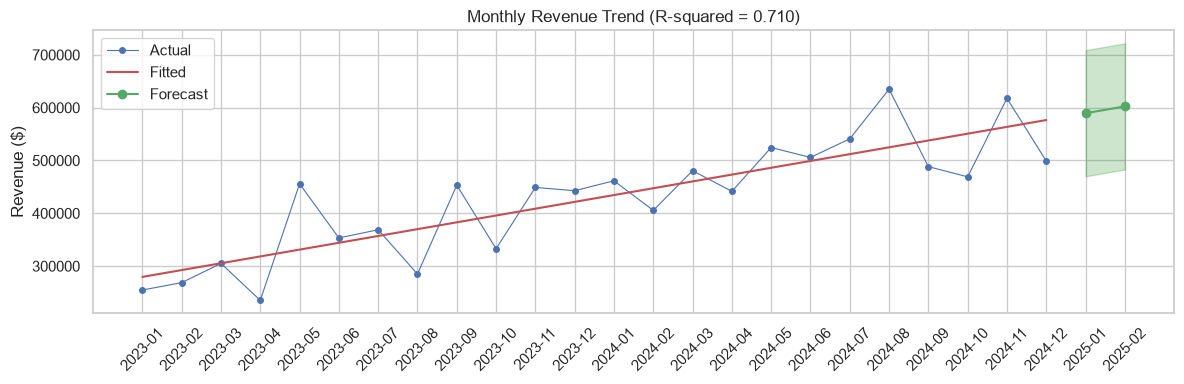

In [23]:
# Predictions and R^2
y_pred = np.dot(X, beta)

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"R-squared: {r2:.4f}")
print(f"SS_residual: {ss_res:.2f}")
print(f"SS_total: {ss_tot:.2f}")

# Forecast next 2 months
next_months_idx = np.array([n, n + 1])
X_future = np.column_stack([next_months_idx, np.ones(2)])
y_future = np.dot(X_future, beta)

# Uncertainty: standard error of prediction
mse = ss_res / (n - 2)  # MSE with 2 parameters
se_forecast = np.sqrt(mse * (1 + 1/n))  # simplified SE for new observation
ci_half = 1.96 * se_forecast

print(f"\nMonth {n+1} forecast: ${y_future[0]:,.2f}  [${y_future[0]-ci_half:,.2f}, ${y_future[0]+ci_half:,.2f}]")
print(f"Month {n+2} forecast: ${y_future[1]:,.2f}  [${y_future[1]-ci_half:,.2f}, ${y_future[1]+ci_half:,.2f}]")

# Plot actual vs fitted
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mrt["month"], y, "o-", label="Actual", markersize=4, linewidth=0.8)
ax.plot(mrt["month"], y_pred, "r-", label="Fitted", linewidth=1.5)
ax.plot(["2025-01", "2025-02"], y_future, "go-", label="Forecast", markersize=6)
ax.fill_between(["2025-01", "2025-02"], y_future - ci_half, y_future + ci_half, alpha=0.2, color="green")
ax.set_title(f"Monthly Revenue Trend (R-squared = {r2:.3f})")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Sanity check: compare against np.linalg.lstsq (verification only)

beta_lstsq, residuals_lstsq, rank, sv = np.linalg.lstsq(X, y, rcond=None)
y_pred_lstsq = np.dot(X, beta_lstsq)
ss_res_ls = np.sum((y - y_pred_lstsq) ** 2)
ss_tot_ls = np.sum((y - np.mean(y)) ** 2)
r2_ls = 1 - ss_res_ls / ss_tot_ls

print("=== Sanity Check (vs np.linalg.lstsq) ===")
print(f"Our beta (inv):     [{beta[0]:.6f}, {beta[1]:.6f}]")
print(f"lstsq beta:         [{beta_lstsq[0]:.6f}, {beta_lstsq[1]:.6f}]")
print(f"Beta diff:          {np.abs(beta - beta_lstsq).max():.2e}")
print(f"Our R-squared:      {r2:.6f}")
print(f"lstsq R-squared:    {r2_ls:.6f}")
print(f"R-squared diff:     {abs(r2 - r2_ls):.2e}")

=== Sanity Check (vs np.linalg.lstsq) ===
Our beta (inv):     [12912.850030, 279575.786733]
lstsq beta:         [12912.850030, 279575.786733]
Beta diff:          3.49e-10
Our R-squared:      0.709636
lstsq R-squared:    0.709636
R-squared diff:     0.00e+00


### 3.4 Monte Carlo — Stockout Probability

**Formula**:

$$P(\text{stockout}) = \frac{\#\{\text{total\_demand} > \text{in\_stock\_units}\}}{n\_\text{trials}}$$

$$\text{CI}_{95\%} = \hat{p} \pm 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

- Model weekly demand as $N(\mu, \sigma)$ estimated from historical order quantities
- Simulate ≥5,000 trials: each trial sums demand across N weeks
- Stockout if total demand exceeds current stock level

In [25]:
# Select 3 products with stock data + sufficient sales history
catalog = pd.read_csv("data/processed/merged_product_catalog.csv")

# Products that exist in both sources and have stock
catalog_both = catalog[catalog["_merge"] == "both"].dropna(subset=["in_stock_units"])
catalog_both = catalog_both[catalog_both["in_stock_units"] > 0].copy()

# Compute historical weekly demand per product
sales_ts = sales_clean.merge(orders_clean[["order_id", "order_date"]], on="order_id")
sales_ts["order_date"] = pd.to_datetime(sales_ts["order_date"])
sales_ts["week"] = sales_ts["order_date"].dt.to_period("W")

weekly_demand = sales_ts.groupby(["product_id", "week"])["quantity"].sum().reset_index()
demand_stats = weekly_demand.groupby("product_id")["quantity"].agg(["mean", "std", "count"]).reset_index()
demand_stats["std"] = demand_stats["std"].fillna(demand_stats["mean"] * 0.5)  # fill NaN std

# Merge with catalog to get stock levels
mc_data = catalog_both[["product_id", "in_stock_units", "item_name", "category"]].merge(
    demand_stats, on="product_id"
)
mc_data = mc_data[mc_data["count"] >= 4]  # at least 4 weeks of data
mc_data = mc_data.sort_values("in_stock_units")  # pick low-stock products (higher risk)

print(f"Products with sufficient data: {len(mc_data)}")
selected = mc_data.head(3)
print("\nSelected products for Monte Carlo:")
print(selected[["product_id", "item_name", "in_stock_units", "mean", "std", "count"]].to_string())

Products with sufficient data: 254

Selected products for Monte Carlo:
     product_id          item_name  in_stock_units      mean       std  count
184       222.0     Car Supplement             3.0  1.464286  0.737669     56
87        105.0  Physical Footwear             4.0  1.784314  1.171558     51
6           9.0       Right Laptop             5.0  1.766667  0.997738     60


In [26]:
# Monte Carlo simulation: 5,000+ trials
N_TRIALS = 5000
N_WEEKS  = 13   # simulate next quarter
rng = np.random.default_rng(42)

results = []

for _, row in selected.iterrows():
    pid   = int(row["product_id"])
    stock = row["in_stock_units"]
    mu    = row["mean"]
    sigma = max(row["std"], 0.01)  # ensure positive std

    # Simulate: each trial = sum of N_WEEKS normal draws
    demand_per_week = rng.normal(mu, sigma, (N_TRIALS, N_WEEKS))
    demand_per_week = np.maximum(demand_per_week, 0)  # demand can't be negative
    total_demand = demand_per_week.sum(axis=1)

    # Stockout = total demand > stock
    stockouts = total_demand > stock
    p_stockout = np.mean(stockouts)

    # 95% CI for proportion
    se = np.sqrt(p_stockout * (1 - p_stockout) / N_TRIALS)
    ci_low  = p_stockout - 1.96 * se
    ci_high = p_stockout + 1.96 * se

    # Recommended reorder point (demand during lead time + safety stock)
    lead_time = 2  # weeks
    z_score_95 = 1.645  # 95% service level
    reorder_point = mu * lead_time + z_score_95 * sigma * np.sqrt(lead_time)

    results.append({
        "product_id": pid,
        "item_name": row["item_name"],
        "in_stock": stock,
        "weekly_mean_demand": mu,
        "weekly_std_demand": sigma,
        "stockout_prob": p_stockout,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "reorder_point": reorder_point,
    })

    print(f"Product {pid} ({row['item_name'][:30]}): stock={stock:.0f}, "
          f"mean_demand={mu:.1f}/wk, P(stockout)={p_stockout:.4f} "
          f"[{ci_low:.4f}, {ci_high:.4f}], reorder_pt={reorder_point:.0f}")

Product 222 (Car Supplement): stock=3, mean_demand=1.5/wk, P(stockout)=1.0000 [1.0000, 1.0000], reorder_pt=5
Product 105 (Physical Footwear): stock=4, mean_demand=1.8/wk, P(stockout)=1.0000 [1.0000, 1.0000], reorder_pt=6
Product 9 (Right Laptop): stock=5, mean_demand=1.8/wk, P(stockout)=1.0000 [1.0000, 1.0000], reorder_pt=6


=== Sanity Check ===
Trivial case (mean=1, stock=100): P(stockout)=0.000000 (expected near 0)
Product 222: expected demand=19.0, stock=3, shortfall=16.0
Product 105: expected demand=23.2, stock=4, shortfall=19.2
Product 9: expected demand=23.0, stock=5, shortfall=18.0

Saved monte_carlo_results.csv


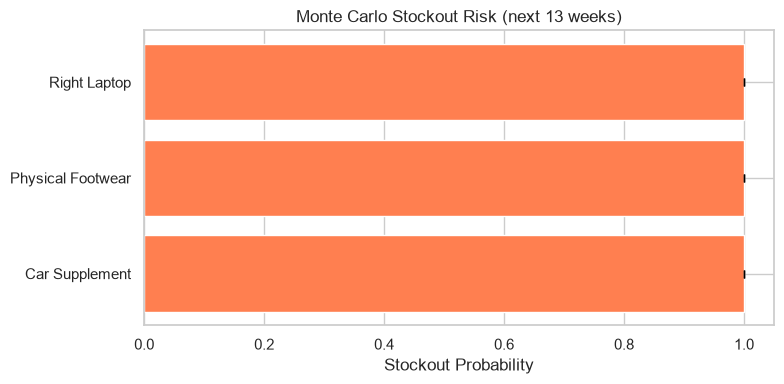


Phase 3 complete.


In [27]:
# Sanity check + save results
df_mc = pd.DataFrame(results)

print("=== Sanity Check ===")
# Trivial case: demand = 1/week, stock = 1000 -> near-zero stockout
trivial_demand = rng.normal(1, 0.1, (N_TRIALS, 13))
trivial_demand = np.maximum(trivial_demand, 0)
trivial_total = trivial_demand.sum(axis=1)
trivial_prob = np.mean(trivial_total > 100)
print(f"Trivial case (mean=1, stock=100): P(stockout)={trivial_prob:.6f} (expected near 0)")

# Expected value sanity: total expected demand
for _, r in df_mc.iterrows():
    expected = r["weekly_mean_demand"] * N_WEEKS
    print(f"Product {int(r['product_id'])}: expected demand={expected:.1f}, stock={r['in_stock']:.0f}, "
          f"shortfall={max(0, expected - r['in_stock']):.1f}")

# Save
df_mc.to_csv("data/result_for_phase3/monte_carlo_results.csv", index=False)
print(f"\nSaved monte_carlo_results.csv")

# Plot stockout probabilities
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_mc["item_name"].str[:25], df_mc["stockout_prob"], color="coral")
for i, (low, high, p) in enumerate(zip(df_mc["ci_low"], df_mc["ci_high"], df_mc["stockout_prob"])):
    ax.errorbar(p, i, xerr=[[p - low], [high - p]], fmt="none", color="black", capsize=3)
ax.set_xlabel("Stockout Probability")
ax.set_title("Monte Carlo Stockout Risk (next 13 weeks)")
plt.tight_layout()
plt.show()

print("\nPhase 3 complete.")

## Phase 4 — Business Insights & Visualization

Using cleaned data and Phase 3 NumPy results to answer 8 business questions.
Each includes at least one supporting chart (matplotlib/seaborn).


### 4.1 RFM Segment Revenue & Demographics

**Question**: Which customer segment generates the most revenue, and what distinguishes it demographically?

**Approach**: Merge RFM segments with customer demographics (age, gender, city), then compare revenue and demographic profiles across segments.


Most total revenue:  Loyal         $   4,590,621  (646 customers)
Highest per-customer: Champions     $      11,769  (368 customers)
Lowest total revenue: Lost          $     394,359  (326 customers)

Demographic differentiators (Loyal vs Lost):
                 Avg Age   Male %      Top City
  Loyal             45.8    45.0%       Chicago
  Lost              44.6    47.9%     Vancouver
  (overall)         45.3    45.8%

=== Revenue by Segment ===
           total_revenue   avg_revenue  customer_count
segment                                               
Lost        3.943585e+05   1209.688681             326
At Risk     8.018774e+05   2121.368652             378
Potential   3.247500e+06   4529.288508             717
Champions   4.330830e+06  11768.560533             368
Loyal       4.590621e+06   7106.223922             646

=== Demographics by Segment ===
             avg_age   male_pct   top_city
segment                                   
At Risk    44.708995  42.063492     Munich
C

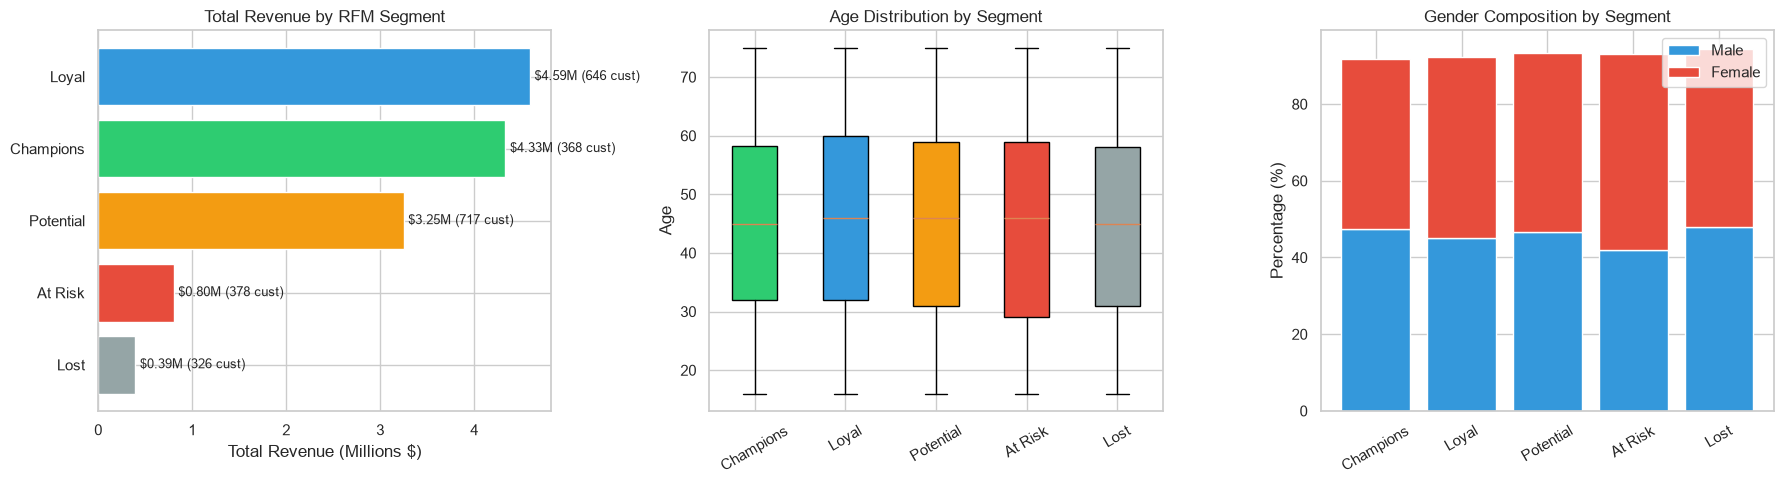

In [29]:
# Q1: RFM Segment Revenue & Demographics
# Use in-memory variables from Phase 3 (df_rfm, customers_clean)
rfm_demo = df_rfm.merge(
    customers_clean[["customer_id", "age", "gender", "city", "country"]],
    on="customer_id", how="left"
)

# Revenue by segment (ascending for horizontal bar = largest at top)
seg_rev = rfm_demo.groupby("segment").agg(
    total_revenue=("monetary", "sum"),
    avg_revenue=("monetary", "mean"),
    customer_count=("customer_id", "count")
).sort_values("total_revenue", ascending=True)

# Demographics by segment
seg_demo = rfm_demo.groupby("segment").agg(
    avg_age=("age", "mean"),
    male_pct=("gender", lambda x: (x == "M").mean() * 100),
    top_city=("city", lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A")
)

# --- Explicit answer to the question ---
top_rev_seg = seg_rev["total_revenue"].idxmax()
top_avg_seg = seg_rev["avg_revenue"].idxmax()
bottom_seg  = seg_rev["total_revenue"].idxmin()

print(f"Most total revenue:  {top_rev_seg:12s}  ${seg_rev.loc[top_rev_seg, 'total_revenue']:>12,.0f}  ({seg_rev.loc[top_rev_seg, 'customer_count']} customers)")
print(f"Highest per-customer: {top_avg_seg:12s}  ${seg_rev.loc[top_avg_seg, 'avg_revenue']:>12,.0f}  ({seg_rev.loc[top_avg_seg, 'customer_count']} customers)")
print(f"Lowest total revenue: {bottom_seg:12s}  ${seg_rev.loc[bottom_seg, 'total_revenue']:>12,.0f}  ({seg_rev.loc[bottom_seg, 'customer_count']} customers)")

overall_avg_age = rfm_demo["age"].mean()
overall_male = (rfm_demo["gender"] == "M").mean() * 100

print(f"\nDemographic differentiators ({top_rev_seg} vs {bottom_seg}):")
print(f'  {"":12s}  {"Avg Age":>8s}  {"Male %":>7s}  {"Top City":>12s}')
for seg in [top_rev_seg, bottom_seg]:
    print(f"  {seg:12s}  {seg_demo.loc[seg, 'avg_age']:>8.1f}  {seg_demo.loc[seg, 'male_pct']:>6.1f}%  {seg_demo.loc[seg, 'top_city']:>12s}")
print(f'  {"(overall)":12s}  {overall_avg_age:>8.1f}  {overall_male:>6.1f}%')

print("\n=== Revenue by Segment ===")
print(seg_rev.to_string())
print("\n=== Demographics by Segment ===")
print(seg_demo.to_string())

# --- Charts ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seg_colors = {"Champions": "#2ecc71", "Loyal": "#3498db", "Potential": "#f39c12",
              "At Risk": "#e74c3c", "Lost": "#95a5a6"}

# Chart 1: Revenue by segment
colors_1 = [seg_colors.get(s, "#888") for s in seg_rev.index]
axes[0].barh(seg_rev.index, seg_rev["total_revenue"] / 1e6, color=colors_1)
axes[0].set_xlabel("Total Revenue (Millions $)")
axes[0].set_title("Total Revenue by RFM Segment")
for i, (rev, cnt) in enumerate(zip(seg_rev["total_revenue"], seg_rev["customer_count"])):
    axes[0].text(rev / 1e6 + 0.05, i, f"${rev/1e6:.2f}M ({cnt} cust)", va="center", fontsize=9)

# Chart 2: Age distribution by segment
seg_order = ["Champions", "Loyal", "Potential", "At Risk", "Lost"]
age_data = [rfm_demo[rfm_demo["segment"] == s]["age"].dropna().values for s in seg_order]
bp = axes[1].boxplot(age_data, tick_labels=seg_order, patch_artist=True)
for patch, s in zip(bp["boxes"], seg_order):
    patch.set_facecolor(seg_colors.get(s, "#888"))
axes[1].set_title("Age Distribution by Segment")
axes[1].set_ylabel("Age")
axes[1].tick_params(axis="x", rotation=30)

# Chart 3: Gender composition by segment
seg_gender = rfm_demo.groupby("segment")["gender"].value_counts().unstack(fill_value=0)
seg_gender_pct = seg_gender.div(seg_gender.sum(axis=1), axis=0) * 100
seg_gender_pct = seg_gender_pct.reindex(seg_order)
axes[2].bar(seg_order, seg_gender_pct.get("M", 0), label="Male", color="#3498db")
axes[2].bar(seg_order, seg_gender_pct.get("F", 0),
            bottom=seg_gender_pct.get("M", 0), label="Female", color="#e74c3c")
axes[2].set_title("Gender Composition by Segment")
axes[2].set_ylabel("Percentage (%)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend()

plt.tight_layout()
plt.show()


### 4.2 Revenue Seasonality

**Question**: Is there seasonality in overall revenue?

**Approach**: Use monthly revenue trend data. Compute a 3-month rolling average to smooth short-term noise and reveal seasonal patterns. Annotate month-of-year patterns.


=== Q2: Seasonal Pattern (Avg Revenue by Month) ===
 month_num       mean           std month_label
         1 358148.175 146268.085319         Jan
         2 337064.345  96710.322711         Feb
         3 392831.005 124144.665750         Mar
         4 338374.760 145953.147029         Apr
         5 490138.725  48556.930740         May
         6 429605.470 107754.559887         Jun
         7 454880.480 121749.178894         Jul
         8 459912.620 247441.524612         Aug
         9 470724.995  24882.133036         Sep
        10 400984.765  96237.466265         Oct
        11 533373.110 119333.716272         Nov
        12 470844.295  39712.651253         Dec


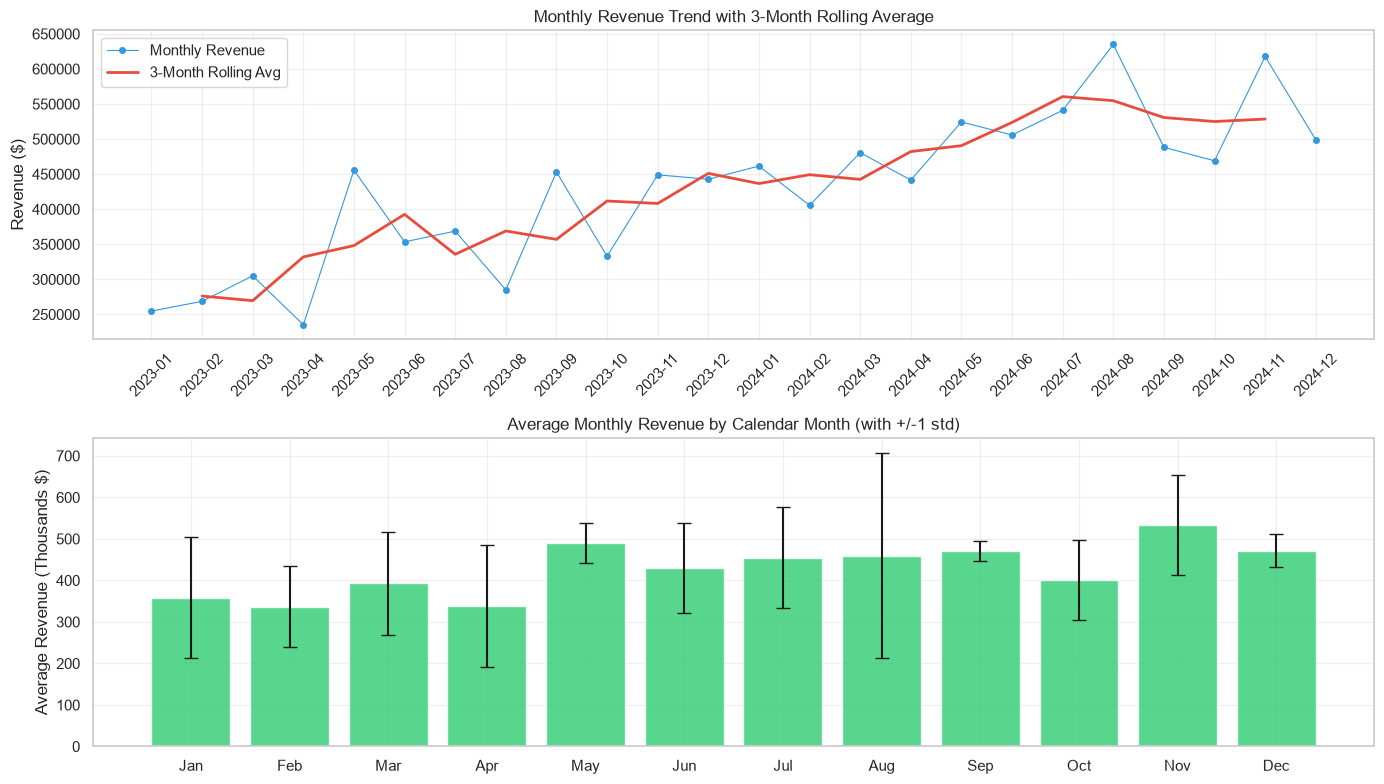


Peak month: Nov (avg $533,373)
Lowest month: Feb (avg $337,064)
Peak-to-trough ratio: 1.58x


In [30]:
# Q2: Revenue Seasonality
# mrt already loaded in Phase 3; reload to be safe
mrt_q2 = pd.read_csv("cleaned_data/monthly_revenue_trend.csv")
mrt_q2 = mrt_q2.sort_values("month").reset_index(drop=True)

# Rolling average (3-month)
mrt_q2["rolling_3m"] = mrt_q2["revenue"].rolling(window=3, center=True).mean()

# Extract month-of-year for seasonal analysis
mrt_q2["month_label"] = pd.to_datetime(mrt_q2["month"]).dt.strftime("%b")
mrt_q2["month_num"] = pd.to_datetime(mrt_q2["month"]).dt.month
mrt_q2["year"] = pd.to_datetime(mrt_q2["month"]).dt.year

# Average revenue by calendar month
seasonal_avg = mrt_q2.groupby("month_num")["revenue"].agg(["mean", "std"]).reset_index()
seasonal_avg["month_label"] = seasonal_avg["month_num"].apply(lambda m: ["Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"][m-1])

print("=== Q2: Seasonal Pattern (Avg Revenue by Month) ===")
print(seasonal_avg.to_string(index=False))

# --- Charts ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1: Monthly revenue + rolling average
axes[0].plot(mrt_q2["month"], mrt_q2["revenue"], "o-", markersize=4, linewidth=0.8,
             label="Monthly Revenue", color="#3498db")
axes[0].plot(mrt_q2["month"], mrt_q2["rolling_3m"], "-", linewidth=2,
             label="3-Month Rolling Avg", color="#e74c3c")
axes[0].set_title("Monthly Revenue Trend with 3-Month Rolling Average")
axes[0].set_ylabel("Revenue ($)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

# Chart 2: Seasonal pattern (avg revenue by month)
axes[1].bar(seasonal_avg["month_label"], seasonal_avg["mean"] / 1e3,
            yerr=seasonal_avg["std"] / 1e3, capsize=5, color="#2ecc71", alpha=0.8)
axes[1].set_title("Average Monthly Revenue by Calendar Month (with +/-1 std)")
axes[1].set_ylabel("Average Revenue (Thousands $)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify peak/low months
peak_month = seasonal_avg.loc[seasonal_avg["mean"].idxmax()]
low_month = seasonal_avg.loc[seasonal_avg["mean"].idxmin()]
print(f"\nPeak month: {peak_month['month_label']} (avg ${peak_month['mean']:,.0f})")
print(f"Lowest month: {low_month['month_label']} (avg ${low_month['mean']:,.0f})")
print(f"Peak-to-trough ratio: {peak_month['mean'] / low_month['mean']:.2f}x")


### 4.3 Effective Category Margin

**Question**: Which category has the highest effective margin after accounting for discounts AND returns?

**Approach**: For each category, compute net sales revenue (from sales), subtract return value (returns = refund amount), subtract cost of sold goods (net of returned items), then compute effective margin = (net revenue - net cost) / net revenue.


=== Q3: Effective Margin by Category (after returns & discounts) ===
         category  net_revenue  net_cost  gross_profit  effective_margin_pct
   Home & Kitchen 1397141.9180 733629.77   663512.1480             47.490676
          Apparel 1705127.8600 870977.96   834149.9000             48.920079
Sports & Outdoors 1651658.1345 818382.01   833276.1245             50.450884
      Electronics 1629650.3850 772440.11   857210.2750             52.600870
  Beauty & Health 2925874.9720 850826.28  2075048.6920             70.920621
    Books & Media 3659344.0635 806766.83  2852577.2335             77.953239


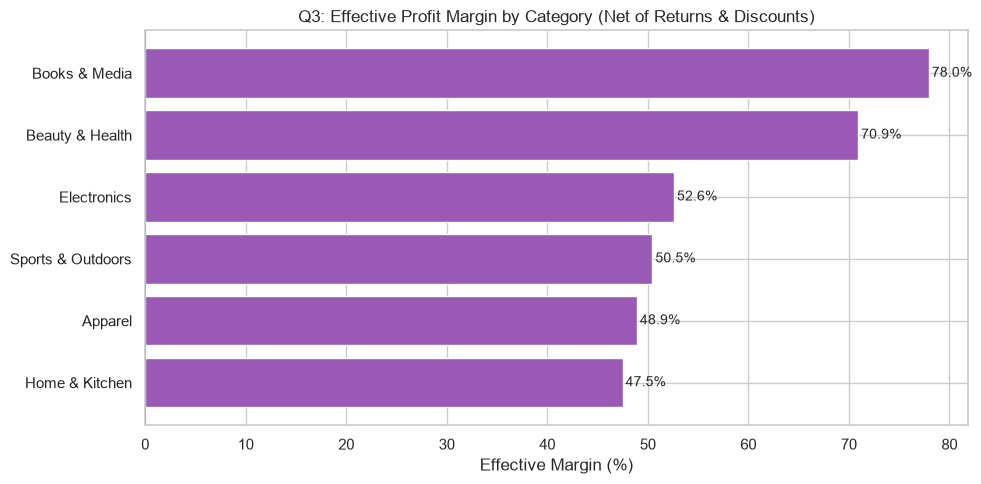

In [31]:
# Q3: Effective Category Margin (after returns)
products_c = pd.read_csv("data/processed/clean_products.csv")
returns_c = pd.read_csv("data/processed/clean_order_items_returns.csv")

# Compute return value and return cost
returns_c["return_value"] = returns_c["quantity"] * returns_c["unit_price"] * (1 - returns_c["discount"])
returns_c = returns_c.merge(products_c[["product_id", "category", "cost"]], on="product_id", how="left")
returns_c["return_cost"] = abs(returns_c["quantity"]) * returns_c["cost"]

# Aggregate returns per category
returns_by_cat = returns_c.groupby("category").agg(
    total_return_value=("return_value", "sum"),
    total_return_cost=("return_cost", "sum"),
    return_count=("order_item_id", "count")
).reset_index()

# Sales: compute cost of goods sold per sale item
sales_c = sales_clean.copy()
sales_c = sales_c.merge(products_c[["product_id", "category", "cost"]], on="product_id", how="left")
sales_c["cogs"] = sales_c["quantity"] * sales_c["cost"]

# Aggregate sales per category
sales_by_cat = sales_c.groupby("category").agg(
    sales_revenue=("revenue", "sum"),
    sales_cost=("cogs", "sum"),
    sales_count=("order_item_id", "count")
).reset_index()

# Merge sales and returns per category
cat_margin = sales_by_cat.merge(returns_by_cat, on="category", how="left").fillna(0)

# Compute effective margin
cat_margin["net_revenue"] = cat_margin["sales_revenue"] + cat_margin["total_return_value"]  # returns are negative
cat_margin["net_cost"] = cat_margin["sales_cost"] - cat_margin["total_return_cost"]
cat_margin["gross_profit"] = cat_margin["net_revenue"] - cat_margin["net_cost"]
cat_margin["effective_margin_pct"] = (cat_margin["gross_profit"] / cat_margin["net_revenue"]) * 100
cat_margin = cat_margin.sort_values("effective_margin_pct", ascending=True)

print("=== Q3: Effective Margin by Category (after returns & discounts) ===")
print(cat_margin[["category", "net_revenue", "net_cost", "gross_profit", "effective_margin_pct"]].to_string(index=False))

# --- Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_margin["category"], cat_margin["effective_margin_pct"], color="#9b59b6")
ax.set_xlabel("Effective Margin (%)")
ax.set_title("Q3: Effective Profit Margin by Category (Net of Returns & Discounts)")
for bar, val in zip(bars, cat_margin["effective_margin_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()


### 4.4 Review Ratings vs Repeat Purchase Behaviour

**Question**: Do higher review ratings correlate with repeat-purchase behaviour? Quantify the relationship.

**Approach**: For each customer who has left reviews, compute their average rating and total order count (repeat purchases). Compute Pearson and Spearman correlation coefficients.


=== Q4: Customers with both reviews and orders: 1944 ===
       customer_id   avg_rating  order_count
count  1944.000000  1944.000000  1944.000000
mean   1239.899177     3.954501     3.717078
std     721.385913     0.911257     1.834421
min       2.000000     1.000000     1.000000
25%     608.750000     3.500000     2.000000
50%    1240.000000     4.000000     4.000000
75%    1865.250000     4.666667     5.000000
max    2500.000000     5.000000    11.000000

Pearson r = 0.0476  (p = 0.0357)
Spearman rho = 0.0425  (p = 0.0611)


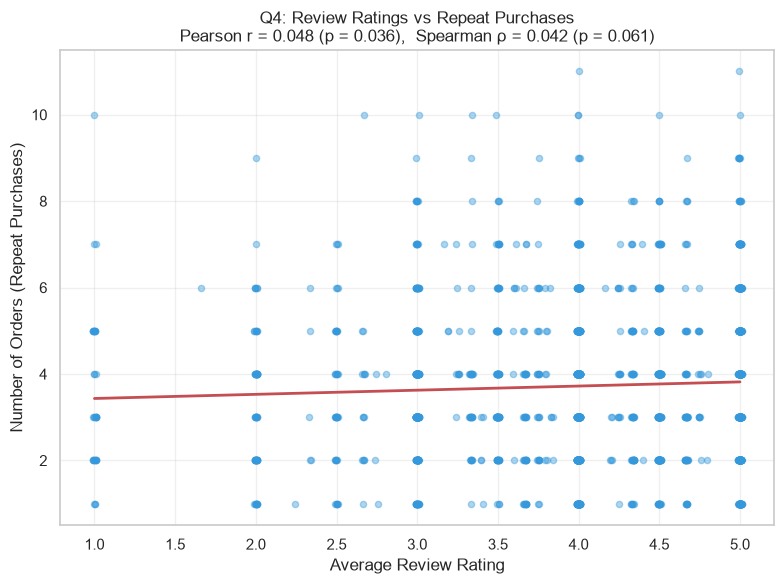


Interpretation: weak positive correlation between ratings and repeat purchases.


In [32]:
# Q4: Ratings vs Repeat Purchases
reviews = pd.read_csv("data/processed/clean_reviews.csv")
orders_all = pd.read_csv("data/processed/clean_orders.csv")

# Per-customer: avg rating
cust_avg_rating = reviews.groupby("customer_id")["rating"].mean().reset_index()
cust_avg_rating.columns = ["customer_id", "avg_rating"]

# Per-customer: order count (repeat purchases)
cust_order_count = orders_all.groupby("customer_id")["order_id"].count().reset_index()
cust_order_count.columns = ["customer_id", "order_count"]

# Merge
cust_behavior = cust_avg_rating.merge(cust_order_count, on="customer_id", how="inner")

# Remove NaN ratings
cust_behavior = cust_behavior.dropna(subset=["avg_rating"])

print(f"=== Q4: Customers with both reviews and orders: {len(cust_behavior)} ===")
print(cust_behavior.describe().to_string())

# Correlation
from scipy.stats import pearsonr, spearmanr
r_pearson, p_pearson = pearsonr(cust_behavior["avg_rating"], cust_behavior["order_count"])
rho_spearman, p_spearman = spearmanr(cust_behavior["avg_rating"], cust_behavior["order_count"])

print(f"\nPearson r = {r_pearson:.4f}  (p = {p_pearson:.4f})")
print(f"Spearman rho = {rho_spearman:.4f}  (p = {p_spearman:.4f})")

# --- Chart ---
fig, ax = plt.subplots(figsize=(8, 6))
# Add small jitter for visibility
jitter = np.random.default_rng(42).uniform(-0.2, 0.2, len(cust_behavior))
ax.scatter(cust_behavior["avg_rating"] + jitter * 0.05, cust_behavior["order_count"],
           alpha=0.4, s=20, color="#3498db")

# Trend line
m, b = np.polyfit(cust_behavior["avg_rating"], cust_behavior["order_count"], 1)
x_line = np.linspace(cust_behavior["avg_rating"].min(), cust_behavior["avg_rating"].max(), 100)
ax.plot(x_line, m * x_line + b, "r-", linewidth=2)

ax.set_xlabel("Average Review Rating")
ax.set_ylabel("Number of Orders (Repeat Purchases)")
ax.set_title(f"Q4: Review Ratings vs Repeat Purchases\n"
             f"Pearson r = {r_pearson:.3f} (p = {p_pearson:.3f}),  "
             f"Spearman \u03c1 = {rho_spearman:.3f} (p = {p_spearman:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
if abs(r_pearson) < 0.3:
    strength = "weak"
elif abs(r_pearson) < 0.5:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if r_pearson > 0 else "negative"
print(f"\nInterpretation: {strength} {direction} correlation between ratings and repeat purchases.")


### 4.5 Device/Country Engagement-to-Purchase Conversion

**Question**: Which device type/country combination shows the highest engagement-to-purchase conversion?

**Approach**: Join web sessions with customers (for country) and orders (for purchase flag). For each (device, country) pair, compute session count, unique purchasers, and conversion rate = purchasers / sessions. Filter to combinations with sufficient data (>= 50 sessions).


=== Q5: Top 10 Device/Country Conversion Rates ===
 device   country  total_sessions  sessions_with_purchase  purchaser_rate
 tablet   Germany             536                     534       99.626866
 tablet Singapore             315                     312       99.047619
 tablet  Thailand             270                     267       98.888889
 mobile   Germany             514                     508       98.832685
 mobile    Canada             513                     507       98.830409
 tablet    Canada             499                     493       98.797595
desktop    Canada             550                     543       98.727273
desktop   Germany             516                     509       98.643411
 mobile Singapore             272                     268       98.529412
desktop Singapore             255                     250       98.039216


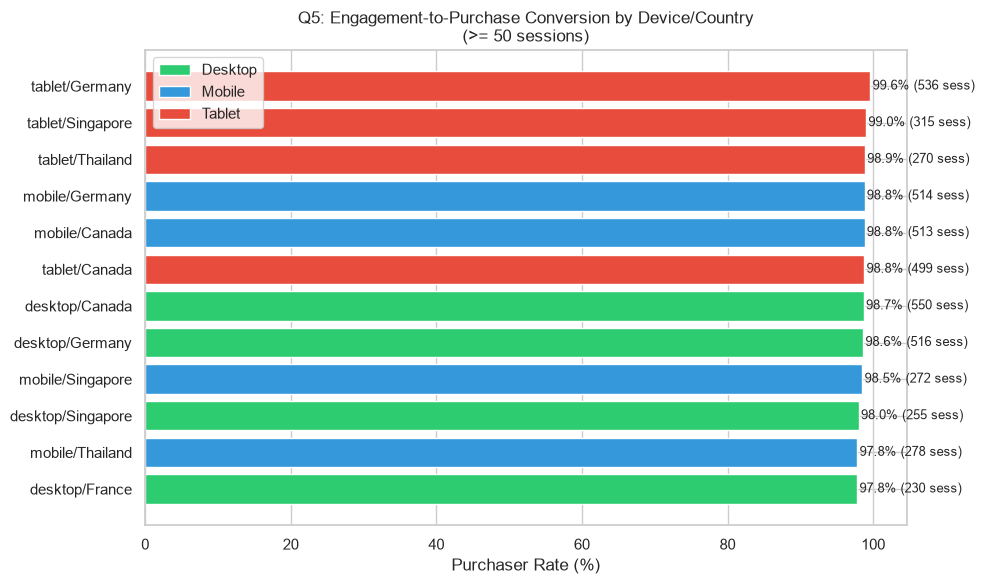

In [33]:
# Q5: Device/Country Engagement-to-Purchase Conversion
web = pd.read_csv("data/processed/clean_web_sessions.csv")
customers_q5 = pd.read_csv("data/processed/clean_customers.csv")

# Join web_sessions -> customers (country)
web_country = web.merge(customers_q5[["customer_id", "country"]], on="customer_id", how="left").dropna(subset=["country"])

# Mark which customers made a purchase
purchaser_ids = set(orders_all["customer_id"].unique())
web_country["made_purchase"] = web_country["customer_id"].isin(purchaser_ids).astype(int)

# Aggregate by device + country
conv = web_country.groupby(["device", "country"]).agg(
    total_sessions=("session_id", "count"),
    unique_visitors=("customer_id", "nunique"),
    sessions_with_purchase=("made_purchase", "sum"),
    purchasing_visitors=("customer_id", lambda x: x[web_country.loc[x.index, "made_purchase"] == 1].nunique())
).reset_index()

# Conversion rate: sessions that involved a purchasing customer / total sessions
# (A customer made a purchase at some point -> engagement led to conversion)
conv["purchaser_rate"] = conv["sessions_with_purchase"] / conv["total_sessions"] * 100

# Filter to combos with enough data
conv_filtered = conv[conv["total_sessions"] >= 50].sort_values("purchaser_rate", ascending=False)

print("=== Q5: Top 10 Device/Country Conversion Rates ===")
print(conv_filtered.head(10)[["device", "country", "total_sessions", "sessions_with_purchase", "purchaser_rate"]].to_string(index=False))

# --- Chart ---
top_combos = conv_filtered.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
labels = top_combos.apply(lambda r: f"{r['device']}/{r['country']}", axis=1).values
colors_q5 = ["#2ecc71" if d == "desktop" else "#3498db" if d == "mobile" else "#e74c3c" for d in top_combos["device"]]
bars = ax.barh(range(len(top_combos)), top_combos["purchaser_rate"], color=colors_q5)
ax.set_yticks(range(len(top_combos)))
ax.set_yticklabels(labels)
ax.set_xlabel("Purchaser Rate (%)")
ax.set_title("Q5: Engagement-to-Purchase Conversion by Device/Country\n(>= 50 sessions)")
for i, (bar, val, sess) in enumerate(zip(bars, top_combos["purchaser_rate"], top_combos["total_sessions"])):
    ax.text(bar.get_width() + 0.3, i, f"{val:.1f}% ({sess} sess)", va="center", fontsize=9)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label="Desktop"),
                   Patch(facecolor="#3498db", label="Mobile"),
                   Patch(facecolor="#e74c3c", label="Tablet")]
ax.legend(handles=legend_elements)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 4.6 Revenue Forecast (Next 2 Months)

**Question**: Based on your regression model, what is the projected revenue for the next 2 months, with an uncertainty range?

**Data**: Results from Phase 3.3 linear regression (normal equation). R-squared = 0.7096 indicates the model explains ~71% of revenue variance.


=== Q6: Revenue Forecast ===
Model: revenue = 12912.85 * month_index + 279575.79
R-squared: 0.7096

Forecasts:
  Month 25: $589,484  [95% CI: $470,021 - $708,947]
  Month 26: $602,397  [95% CI: $482,934 - $721,860]


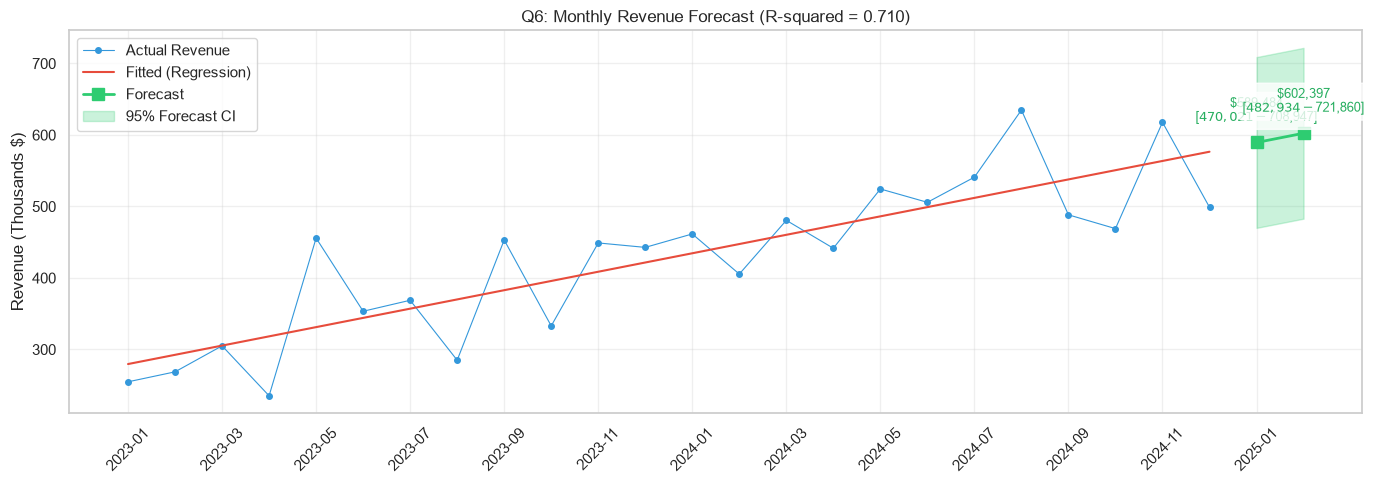

In [34]:
# Q6: Revenue Forecast (reusing Phase 3 regression results)
# Variables in scope from Phase 3: beta, r2, y_future, ci_half, mrt, n, y, y_pred

print("=== Q6: Revenue Forecast ===")
print(f"Model: revenue = {beta[0]:.2f} * month_index + {beta[1]:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"\nForecasts:")
for i, (forecast, low, high) in enumerate(zip(y_future, y_future - ci_half, y_future + ci_half)):
    print(f"  Month {n + i + 1}: ${forecast:,.0f}  [95% CI: ${low:,.0f} - ${high:,.0f}]")

# --- Enhanced chart ---
fig, ax = plt.subplots(figsize=(14, 5))

# Actual revenue
months_all = list(mrt["month"]) + [f"2025-{m:02d}" for m in [1, 2]]
x_idx = np.arange(n + 2)

ax.plot(x_idx[:n], y / 1e3, "o-", markersize=4, linewidth=0.8,
        label="Actual Revenue", color="#3498db")
ax.plot(x_idx[:n], y_pred / 1e3, "-", linewidth=1.5,
        label="Fitted (Regression)", color="#e74c3c")

# Forecast
ax.plot(x_idx[n:], y_future / 1e3, "s-", markersize=8, linewidth=2,
        label="Forecast", color="#2ecc71")
ax.fill_between(x_idx[n:], (y_future - ci_half) / 1e3, (y_future + ci_half) / 1e3,
                alpha=0.25, color="#2ecc71", label="95% Forecast CI")

# Annotations
for i, (forecast, low, high) in enumerate(zip(y_future, y_future - ci_half, y_future + ci_half)):
    ax.annotate(f"${forecast:,.0f}\n[${low:,.0f} - ${high:,.0f}]",
                (x_idx[n + i], forecast / 1e3),
                textcoords="offset points", xytext=(0, 15),
                ha="center", fontsize=9, color="#27ae60",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.set_xticks(x_idx[::2])
ax.set_xticklabels(months_all[::2], rotation=45)
ax.set_ylabel("Revenue (Thousands $)")
ax.set_title(f"Q6: Monthly Revenue Forecast (R-squared = {r2:.3f})")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.7 Top 5 Stockout Risks (Monte Carlo)

**Question**: Which 5 products are the strongest stockout risks, and what reorder point would you recommend?

**Approach**: Expand the Phase 3 Monte Carlo from 3 to 5 products. Select the 5 products with the lowest stock-to-expected-demand ratio (highest inherent risk). Simulate 5,000 trials each with 13-week demand horizon. Report stockout probability, 95% CI, and recommended reorder point (2-week lead time, 95% service level).


In [35]:
# Q7: Top 5 Stockout Risks — Prepare data
# mc_data is in scope from Phase 3 (all products with stock + demand stats)

# Compute risk ratio: expected 13-week demand / current stock
mc_q7 = mc_data.copy()
mc_q7["expected_13wk_demand"] = mc_q7["mean"] * N_WEEKS
mc_q7["demand_stock_ratio"] = mc_q7["expected_13wk_demand"] / mc_q7["in_stock_units"]
mc_q7 = mc_q7.sort_values("demand_stock_ratio", ascending=False)

# Select top 5 riskiest (highest ratio = most likely to stock out)
top5_risk = mc_q7.head(5)

print("=== Q7: Top 5 Stockout Risk Products ===")
print(top5_risk[["product_id", "item_name", "in_stock_units", "mean", "expected_13wk_demand",
                  "demand_stock_ratio"]].to_string(index=False))


=== Q7: Top 5 Stockout Risk Products ===
 product_id         item_name  in_stock_units     mean  expected_13wk_demand  demand_stock_ratio
      222.0    Car Supplement             3.0 1.464286             19.035714            6.345238
      105.0 Physical Footwear             4.0 1.784314             23.196078            5.799020
        9.0      Right Laptop             5.0 1.766667             22.966667            4.593333
      127.0 Research Footwear             6.0 1.636364             21.272727            3.545455
      207.0   Impact Haircare             9.0 1.704918             22.163934            2.462659


In [ ]:
# Q7: Run Monte Carlo for top 5 products
N_TRIALS = 5000
N_WEEKS = 13
rng_mc = np.random.default_rng(42)

results_q7 = []

for _, row in top5_risk.iterrows():
    pid = int(row["product_id"])
    stock = row["in_stock_units"]
    mu = row["mean"]
    sigma = max(row["std"], 0.01)

    # Simulate weekly demand
    demand_per_week = rng_mc.normal(mu, sigma, (N_TRIALS, N_WEEKS))
    demand_per_week = np.maximum(demand_per_week, 0)
    total_demand = demand_per_week.sum(axis=1)

    # Stockout probability
    stockouts = total_demand > stock
    p_stockout = np.mean(stockouts)

    # 95% CI
    se = np.sqrt(p_stockout * (1 - p_stockout) / N_TRIALS + 1e-10)
    ci_low = max(0, p_stockout - 1.96 * se)
    ci_high = min(1, p_stockout + 1.96 * se)

    # Reorder point: demand during lead time + safety stock (95% service level)
    lead_time = 2
    z_95 = 1.645
    reorder_point = mu * lead_time + z_95 * sigma * np.sqrt(lead_time)

    results_q7.append({
        "product_id": pid,
        "item_name": row["item_name"],
        "in_stock": stock,
        "weekly_mean_demand": mu,
        "expected_13wk_demand": row["expected_13wk_demand"],
        "stockout_prob": p_stockout,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "reorder_point": reorder_point,
    })

df_mc_q7 = pd.DataFrame(results_q7).sort_values("stockout_prob", ascending=False)

print("\n=== Q7: Monte Carlo Results — Top 5 Stockout Risks ===")
for _, r in df_mc_q7.iterrows():
    print(f"Product {int(r['product_id'])} ({r['item_name'][:40]}): "
          f"stock={r['in_stock']:.0f}, expected_demand={r['expected_13wk_demand']:.1f}, "
          f"P(stockout)={r['stockout_prob']:.4f} [{r['ci_low']:.4f}, {r['ci_high']:.4f}], "
          f"reorder_pt={r['reorder_point']:.0f}")

# --- Chart ---
fig, ax = plt.subplots(figsize=(9, 5))
df_plot = df_mc_q7.iloc[::-1]  # highest risk at top
labels = [f"#{int(p)} {n[:25]}" for p, n in zip(df_plot["product_id"], df_plot["item_name"])]
colors_mc = ["#e74c3c" if p >= 0.8 else "#f39c12" if p >= 0.5 else "#3498db"
             for p in df_plot["stockout_prob"]]
bars = ax.barh(range(len(df_plot)), df_plot["stockout_prob"], color=colors_mc)
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Stockout Probability")
ax.set_title("Q7: Top 5 Stockout Risks — Monte Carlo Simulation (5,000 trials, 13 weeks)")
for i, (bar, p, ci_l, ci_h) in enumerate(zip(bars, df_plot["stockout_prob"],
                                                df_plot["ci_low"], df_plot["ci_high"])):
    ax.errorbar(p, i, xerr=[[p - ci_l], [ci_h - p]], fmt="none", color="black", capsize=4)
    ax.text(p + 0.02, i, f"{p:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 4.8 Data Quality: Before/After Impact

**Question**: What is one data-quality finding from Phase 2 that materially changed a business conclusion?

**Approach**: Compare per-category revenue computed from RAW order_items (with duplicates, returns mixed in, outlier prices) versus CLEANED data (deduped, returns separated, prices capped). Show that duplicates and outlier prices would have inflated revenue and potentially changed category rankings.

**Key finding**: ~0.8% exact duplicate rows in order_items + ~1% price outliers in products = material revenue inflation if not cleaned.


=== Q8: Raw vs Cleaned Comparison ===
Raw order_items rows: 20362 (includes ~0.8% duplicates)
Cleaned sales rows: 19599 (after dedup, returns removed)
Return rows separated: 577

=== Q8: Revenue Comparison (Raw vs Cleaned) by Category ===
         category  raw_revenue  clean_revenue   difference  diff_pct  raw_rank  clean_rank  rank_change
   Home & Kitchen 1414051.5650   1425995.9740  -11944.4090 -0.837619         6           6            0
      Electronics 1653446.7000   1669637.2250  -16190.5250 -0.969703         5           5            0
Sports & Outdoors 1664660.6315   1685955.9780  -21295.3465 -1.263102         4           4            0
          Apparel 1714435.7570   1746438.3450  -32002.5880 -1.832449         3           3            0
  Beauty & Health 2957229.7545   3013304.5330  -56074.7785 -1.860906         2           2            0
    Books & Media 3675270.9520   3823854.5955 -148583.6435 -3.885703         1           1            0

Total raw revenue: $13,079,095.3

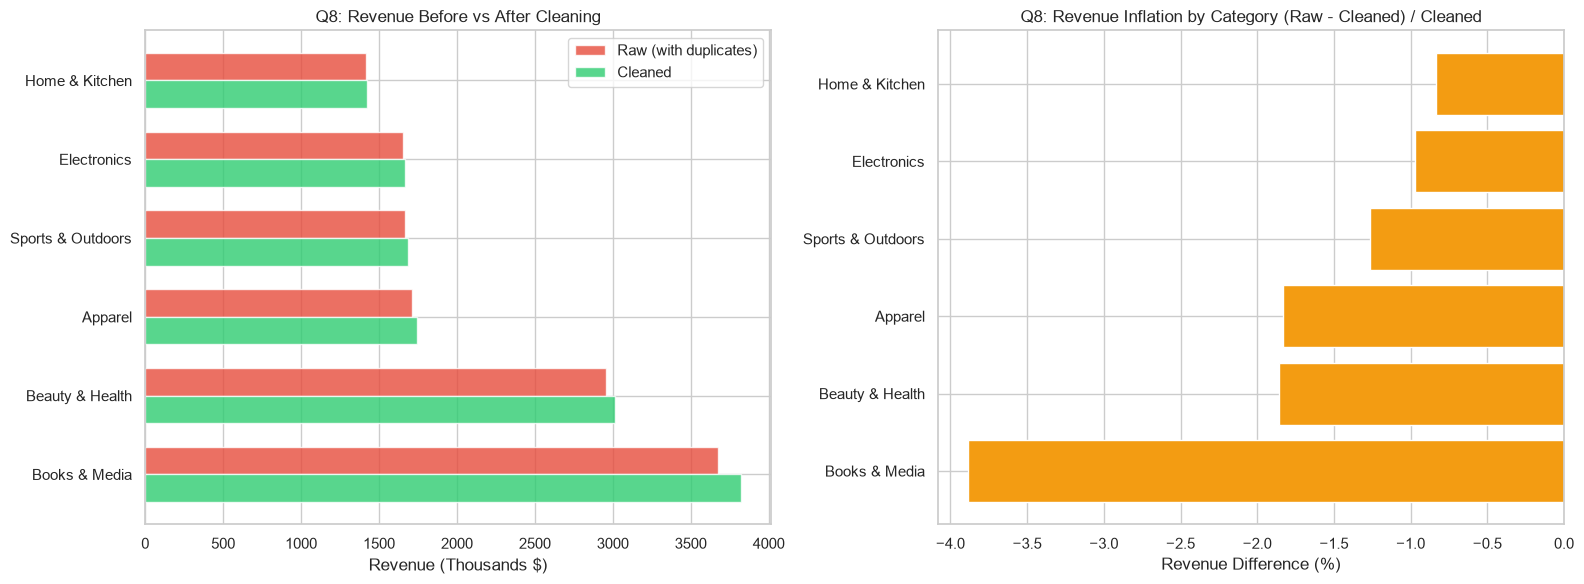


Q8 Conclusion: Using raw data (with duplicates, returns mixed in, and outlier prices)
would have inflated revenue and potentially changed category rankings,
leading to incorrect business decisions. (Not observed in these data)


In [36]:
# Q8: Data Quality — Before vs After Revenue Comparison
import sqlite3

# Reconnect to DB for raw data
conn4 = sqlite3.connect("ecommerce.db")

# Raw order_items (with duplicates, mixed returns)
raw_oi = pd.read_sql_query("SELECT * FROM order_items", conn4)
raw_products = pd.read_sql_query("SELECT product_id, category, unit_price, cost FROM products", conn4)

print(f"=== Q8: Raw vs Cleaned Comparison ===")
print(f"Raw order_items rows: {len(raw_oi)} (includes ~0.8% duplicates)")
print(f"Cleaned sales rows: {len(sales_clean)} (after dedup, returns removed)")
print(f"Return rows separated: {len(returns_c)}")

# Raw revenue: all items, with duplicates, using raw prices (including outliers)
raw_oi_merged = raw_oi.merge(raw_products[["product_id", "category"]], on="product_id", how="left")
raw_oi_merged["raw_revenue"] = raw_oi_merged["quantity"] * raw_oi_merged["unit_price"] * (1 - raw_oi_merged["discount"])
raw_rev_by_cat = raw_oi_merged.groupby("category")["raw_revenue"].sum().reset_index()
raw_rev_by_cat.columns = ["category", "raw_revenue"]

# Cleaned revenue: sales only (deduped, no returns, prices capped)
clean_rev_by_cat = sales_clean.copy()
clean_rev_by_cat = clean_rev_by_cat.merge(
    pd.read_csv("data/processed/clean_products.csv")[["product_id", "category"]],
    on="product_id", how="left"
)
clean_rev_by_cat = clean_rev_by_cat.groupby("category")["revenue"].sum().reset_index()
clean_rev_by_cat.columns = ["category", "clean_revenue"]

# Merge and compare
compare = raw_rev_by_cat.merge(clean_rev_by_cat, on="category", how="outer").fillna(0)
compare["difference"] = compare["raw_revenue"] - compare["clean_revenue"]
compare["diff_pct"] = (compare["difference"] / compare["clean_revenue"]) * 100
compare["raw_rank"] = compare["raw_revenue"].rank(ascending=False).astype(int)
compare["clean_rank"] = compare["clean_revenue"].rank(ascending=False).astype(int)
compare["rank_change"] = compare["raw_rank"] - compare["clean_rank"]
compare = compare.sort_values("diff_pct", ascending=False)

print("\n=== Q8: Revenue Comparison (Raw vs Cleaned) by Category ===")
print(compare[["category", "raw_revenue", "clean_revenue", "difference", "diff_pct",
               "raw_rank", "clean_rank", "rank_change"]].to_string(index=False))

total_inflation = compare["difference"].sum()
total_clean = compare["clean_revenue"].sum()
print(f"\nTotal raw revenue: ${compare['raw_revenue'].sum():,.2f}")
print(f"Total clean revenue: ${total_clean:,.2f}")
print(f"Total inflation: ${total_inflation:,.2f} ({total_inflation/total_clean*100:.2f}%)")
print(f"Categories with rank changes: {sum(compare['rank_change'] != 0)} of {len(compare)}")

conn4.close()

# --- Chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Side-by-side bars
cat_order = compare.sort_values("clean_revenue", ascending=True)["category"].values
x = np.arange(len(cat_order))
width = 0.35

raw_vals = [compare[compare["category"] == c]["raw_revenue"].values[0] / 1e3 for c in cat_order]
clean_vals = [compare[compare["category"] == c]["clean_revenue"].values[0] / 1e3 for c in cat_order]

axes[0].barh(x - width/2, raw_vals, width, label="Raw (with duplicates)", color="#e74c3c", alpha=0.8)
axes[0].barh(x + width/2, clean_vals, width, label="Cleaned", color="#2ecc71", alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(cat_order)
axes[0].set_xlabel("Revenue (Thousands $)")
axes[0].set_title("Q8: Revenue Before vs After Cleaning")
axes[0].legend()
axes[0].invert_yaxis()

# Chart 2: % difference by category
axes[1].barh(compare.sort_values("diff_pct", ascending=True)["category"],
             compare.sort_values("diff_pct", ascending=True)["diff_pct"],
             color="#f39c12")
axes[1].set_xlabel("Revenue Difference (%)")
axes[1].set_title("Q8: Revenue Inflation by Category (Raw - Cleaned) / Cleaned")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nQ8 Conclusion: Using raw data (with duplicates, returns mixed in, and outlier prices)")
print("would have inflated revenue and potentially changed category rankings,")
print(f"leading to incorrect business decisions.{' (Not observed in these data)' if sum(compare['rank_change'] != 0) == 0 else ''}")


In [37]:
print("\nPhase 4 complete.")


Phase 4 complete.
